In [1]:
import pandas as pd

# Importa il dataframe dal file compresso .csv.gz
df = pd.read_csv(
    "data_10_24.csv.gz",
    parse_dates=True,
    index_col=0
)

# Visualizza le prime righe
df

,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WTW,WY,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,NaN,NaN,NaN,NaN,18.763718,NaN,NaN,NaN,NaN,21.239878,...,52.549011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,NaN,NaN,NaN,NaN,18.612118,NaN,NaN,NaN,NaN,21.354618,...,52.431255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,NaN,NaN,NaN,NaN,18.715481,NaN,NaN,NaN,NaN,21.300613,...,53.275311,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,NaN,NaN,NaN,NaN,18.870522,NaN,NaN,NaN,NaN,21.077894,...,53.118282,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-08,NaN,NaN,NaN,NaN,18.966991,NaN,NaN,NaN,NaN,20.814674,...,53.059380,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-16,NaN,NaN,171.630005,NaN,112.620003,NaN,NaN,NaN,NaN,51.689999,...,313.149994,NaN,NaN,NaN,NaN,120.779999,NaN,NaN,NaN,NaN
2024-12-17,NaN,NaN,175.380005,NaN,113.290001,NaN,NaN,NaN,NaN,51.490002,...,310.529999,NaN,NaN,NaN,NaN,120.769997,NaN,NaN,NaN,NaN
2024-12-18,NaN,NaN,173.020004,NaN,111.930000,NaN,NaN,NaN,NaN,49.849998,...,307.549988,NaN,NaN,NaN,NaN,116.919998,NaN,NaN,NaN,NaN


In [2]:
df.shape

(3768, 502)

Rimuovo le serie non abbastanza complete.

In [3]:
# 
# contare il numero di NaN per ciascun ticker.

nan_counts = df.isna().sum()

# Ordine decrescente
nan_counts = nan_counts.sort_values(ascending=False)

print(nan_counts)

ZTS     3768
A       3768
AAPL    3768
ZBRA    3768
ABNB    3768
        ... 
UDR        0
UPS        0
AES        0
ADM        0
ABT        0
Length: 502, dtype: int64


In [4]:
# 
# mostrare solo i ticker con dati mancanti.

nan_counts_nonzero = nan_counts[nan_counts > 0]

print(nan_counts_nonzero)

ZTS     3768
A       3768
AAPL    3768
ZBRA    3768
ABNB    3768
        ... 
ENPH     565
XYL      449
HII      306
HCA      298
TSLA     122
Length: 352, dtype: int64


In [5]:
# 
# calcolare la percentuale di NaN per ticker.

nan_percent = 100 * df.isna().mean()

summary_nan = pd.DataFrame({
    "n_nan": nan_counts,
    "pct_nan": nan_percent
})

summary_nan = summary_nan.sort_values(
    "pct_nan",
    ascending=False
)

print(summary_nan)

      n_nan  pct_nan
ZTS    3768    100.0
A      3768    100.0
AAPL   3768    100.0
ZBRA   3768    100.0
ABNB   3768    100.0
...     ...      ...
UDR       0      0.0
UPS       0      0.0
AES       0      0.0
ADM       0      0.0
ABT       0      0.0

[502 rows x 2 columns]


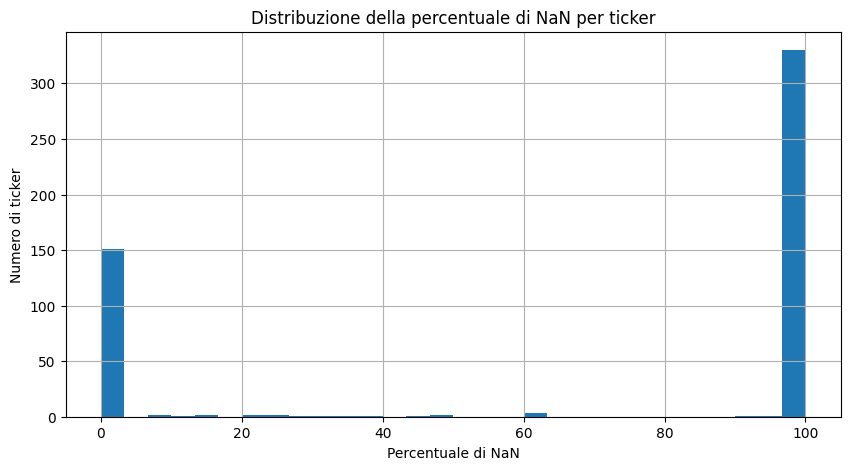

In [6]:
# 
# visualizzare la distribuzione delle percentuali di NaN
# tramite un istogramma.

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(summary_nan.pct_nan, bins=30)

plt.title("Distribuzione della percentuale di NaN per ticker")

plt.xlabel("Percentuale di NaN")

plt.ylabel("Numero di ticker")

plt.grid(True)

plt.show()

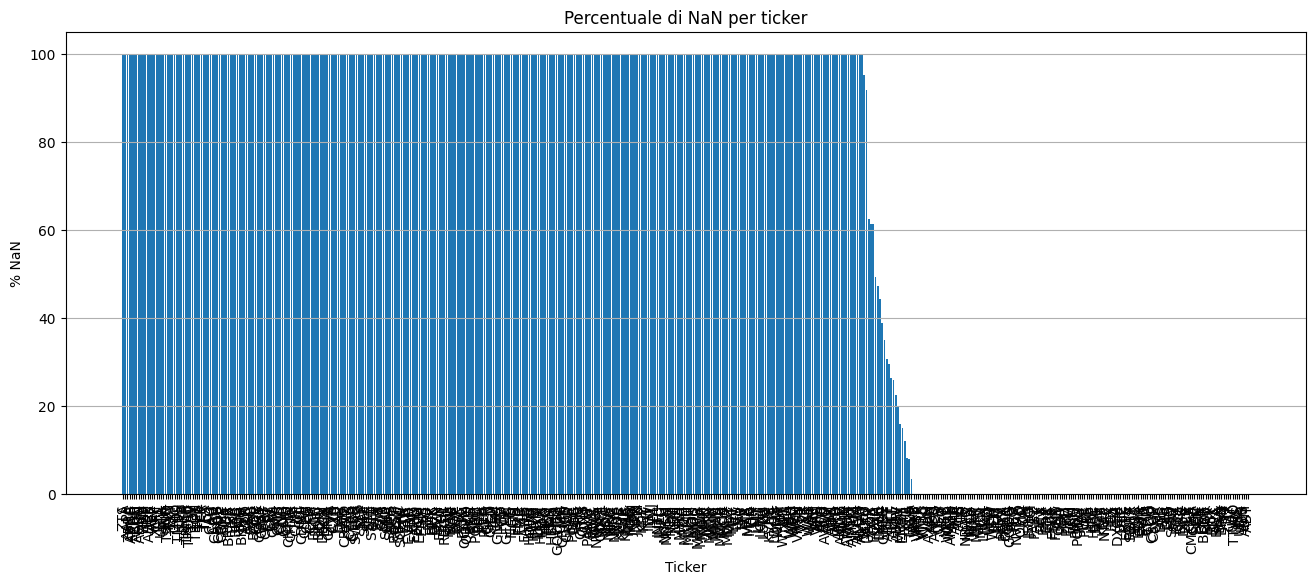

In [7]:
# 
# plottare la percentuale di NaN per ciascun ticker.

# Percentuale di NaN per ticker
pct_nan = 100 * df.isna().mean()

# Ordinamento decrescente
pct_nan_sorted = pct_nan.sort_values(ascending=False)

# Plot
plt.figure(figsize=(16, 6))

plt.bar(
    pct_nan_sorted.index,
    pct_nan_sorted.values
)

plt.title("Percentuale di NaN per ticker")

plt.xlabel("Ticker")

plt.ylabel("% NaN")

plt.xticks(rotation=90)

plt.grid(True, axis='y')

plt.show()

In [8]:
# Butto via i ticker in cui n. di NaN > 5%

# Numero di date (righe del dataframe)
n_dates = len(df.index)

print(f"Numero di date: {n_dates}")

# Percentuale di NaN per ciascuna azione
nan_ratio = df.isna().mean()

# Ticker da mantenere: <= 5% di NaN
valid_tickers = nan_ratio[nan_ratio <= 0.05].index

# Dataframe filtrato
df_filtered = df[valid_tickers]

# Numero di azioni rimaste
n_remaining = df_filtered.shape[1]

print(f"Numero di azioni rimaste: {n_remaining}")

Numero di date: 3768
Numero di azioni rimaste: 151


In [9]:
# Interpolazione temporale dei valori mancanti
# Usa le quotazioni più vicine nel tempo

df_filtered.index = pd.to_datetime(df_filtered.index)
df_filtered = df_filtered.sort_index()

df_filled = df_filtered.interpolate(
    method="time",
    limit_direction="both"
)

# Controllo finale
print(df_filled.isna().sum().sum(), "NaN rimanenti")

0 NaN rimanenti


## Log-rendimenti

In [10]:
import numpy as np

# Rendimenti logaritmici giornalieri
log_returns = np.log(df_filled / df_filled.shift(1))

# Elimina la prima riga (NaN dovuti allo shift)
log_returns = log_returns.iloc[1:]

# Controllo
print(log_returns.shape)
log_returns.head()

(3767, 151)


,ABT,ADM,AES,AJG,ALB,ALL,AMP,AMZN,ANSS,AOS,...,VRSK,VRTX,VTRS,WDC,WEC,WELL,WMB,WRB,WST,WTW
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,-0.008112,0.005388,-0.010294,-0.005388,-0.001840,0.016308,0.023053,0.005883,-0.022656,-0.012860,...,0.006678,-0.033559,-0.010741,0.026168,-0.013157,0.013979,0.012416,-0.003679,-0.012749,-0.002243
2010-01-06,0.005538,-0.002532,-0.010402,0.000450,0.001840,0.000323,0.013870,-0.018282,-0.006667,0.000454,...,0.012895,-0.017687,-0.009767,0.000860,0.010136,-0.004938,0.031934,0.002045,-0.009799,0.015970
2010-01-07,0.008250,-0.010511,0.000747,-0.006321,-0.007114,0.005161,0.007463,-0.017160,0.002534,0.002946,...,-0.001644,-0.012690,-0.017047,-0.019764,-0.002019,0.002023,-0.007107,0.004079,0.003105,-0.002952
2010-01-08,0.005099,-0.012567,0.027964,0.002714,0.014959,0.004174,0.003592,0.026717,0.006879,0.014602,...,-0.012916,-0.020203,-0.034418,0.005032,0.005843,-0.010384,0.007993,-0.000814,-0.000259,-0.001110
2010-01-11,0.005073,0.000648,0.006510,0.001354,-0.004438,0.000000,0.012824,-0.024335,0.003877,-0.004694,...,-0.002336,0.028123,0.019893,0.001091,0.014759,0.002266,-0.006211,0.002035,-0.004402,0.009939


In [11]:
# Statistiche descrittive dei rendimenti
stats = log_returns.describe().T

# Aggiungiamo skewness e kurtosis
stats["skew"] = log_returns.skew()
stats["kurtosis"] = log_returns.kurtosis()

# Valori estremi assoluti
stats["min"] = log_returns.min()
stats["max"] = log_returns.max()

# Visualizza le azioni con i movimenti più estremi
extreme_moves = (
    stats.assign(
        max_abs_move=lambda x: np.maximum(np.abs(x["min"]), np.abs(x["max"]))
    )
    .sort_values("max_abs_move", ascending=False)
)

print(extreme_moves[["min", "max", "max_abs_move", "skew", "kurtosis"]].head(20))

           min       max  max_abs_move      skew   kurtosis
DXCM -0.521858  0.267333      0.521858 -1.704820  38.840438
BLDR -0.264883  0.516894      0.516894  0.817709  18.686669
VRTX -0.231875  0.481849      0.481849  3.549162  67.371900
NFLX -0.432578  0.352230      0.432578 -0.945571  29.676382
WMB  -0.427911  0.295550      0.427911 -1.313440  48.623187
EXPE -0.408806  0.219671      0.408806 -1.829180  34.530550
CCL  -0.403190  0.331394      0.403190 -1.319474  26.680148
EQIX -0.401477  0.124458      0.401477 -2.434985  60.185305
DG   -0.387817  0.128521      0.387817 -3.353236  66.382680
FSLR -0.292121  0.375179      0.375179  0.342462  10.314961
UAL  -0.360829  0.228842      0.360829 -0.467162  12.518053
BBY  -0.336685  0.194576      0.336685 -0.701462  17.803966
PWR  -0.335481  0.148130      0.335481 -1.290318  24.143907
PARA -0.333419  0.268212      0.333419 -1.138891  22.607343
EQT  -0.206504  0.317143      0.317143  0.417811   8.207131
STZ  -0.190988  0.316513      0.316513  

Qua sopra, da skew e kurtosis si vede la non-normalità.

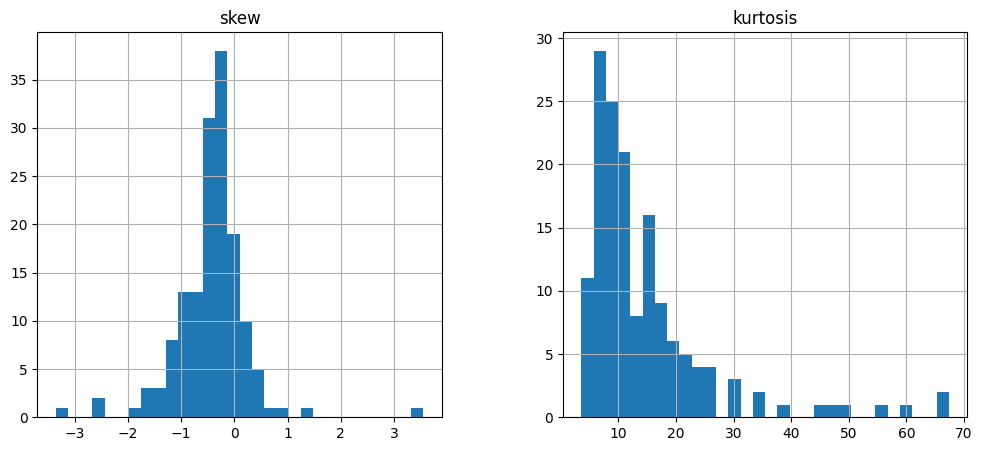

In [12]:
# 
# vedere la distribuzione di skewness e kurtosis
# tra i ticker.

stats = pd.DataFrame({
    "skew": log_returns.skew(),
    "kurtosis": log_returns.kurt()
})

stats.hist(figsize=(12,5), bins=30)

plt.show()

Osservazione degli outlier.

In [13]:
# Z-score per ciascuna serie
z_scores = (log_returns - log_returns.mean()) / log_returns.std()

# Celle con |z| > 5
outliers = (np.abs(z_scores) > 5)

# Conteggio totale
n_outliers = outliers.sum().sum()

print(f"Numero totale di outlier con |z| > 5: {n_outliers}")
print(f"Numero totale di rendimenti: {log_returns.size}")
print(f"Frazione di outlier: {n_outliers / log_returns.size}")

Numero totale di outlier con |z| > 5: 1794
Numero totale di rendimenti: 568817
Frazione di outlier: 0.003153914176264071


In [14]:
# Elenco degli outlier
outlier_positions = np.where(np.abs(z_scores) > 5)

outlier_df = pd.DataFrame({
    "date": log_returns.index[outlier_positions[0]],
    "ticker": log_returns.columns[outlier_positions[1]],
    "log_return": log_returns.values[outlier_positions],
    "z_score": z_scores.values[outlier_positions]
})

outlier_df.sort_values("z_score", key=np.abs, ascending=False).head(5)

,date,ticker,log_return,z_score
28,2010-10-06,EQIX,-0.401477,-21.480272
1768,2024-08-29,DG,-0.387817,-21.177478
252,2013-04-19,VRTX,0.481849,18.676267
882,2020-03-16,O,-0.286755,-18.364857
240,2013-02-14,STZ,0.316513,17.919876


In [15]:
stats.sort_values("kurtosis", ascending=False).head(5)

,skew,kurtosis
VRTX,3.549162,67.371900
DG,-3.353236,66.382680
EQIX,-2.434985,60.185305
O,-2.653042,56.691664
WMB,-1.313440,48.623187


In [16]:
# Prendiamo un ticker e guardiamolo

ticker = "VRTX"

<Axes: >

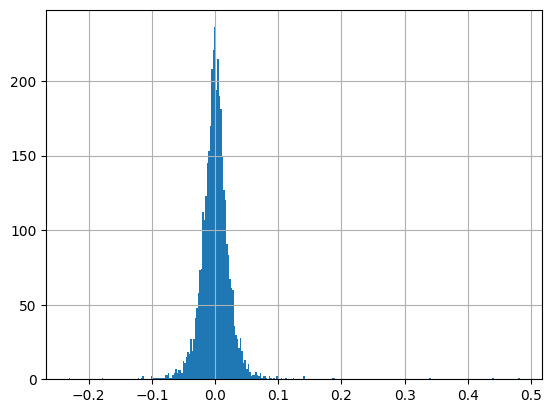

In [17]:
log_returns[ticker].hist(bins=300)

Scala logaritmica per vedere le code.

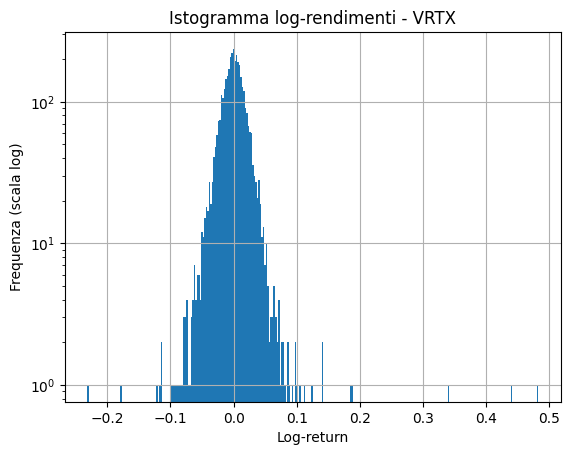

In [18]:
# 
# visualizzare l'istogramma dei log-rendimenti
# con asse y in scala logaritmica.

log_returns[ticker].hist(
    bins=300,
    log=True
)

plt.xlabel("Log-return")
plt.ylabel("Frequenza (scala log)")

plt.title(f"Istogramma log-rendimenti - {ticker}")

plt.grid(True)

plt.show()

In [19]:
# Rendimenti più estremi di VRTX
log_returns["VRTX"].sort_values().head(5)

Date
2020-10-15   -0.231875
2012-06-28   -0.177327
2024-12-19   -0.120647
2021-06-11   -0.116043
2012-05-29   -0.115088
Name: VRTX, dtype: float64

In [20]:
log_returns["VRTX"].nlargest(5)

Date
2013-04-19    0.481849
2012-05-07    0.440572
2014-06-24    0.339428
2017-07-19    0.189221
2017-03-29    0.186088
Name: VRTX, dtype: float64

In [21]:
stats.loc["VRTX"]

skew         3.549162
kurtosis    67.371900
Name: VRTX, dtype: float64

Vedere andamento prezzo.

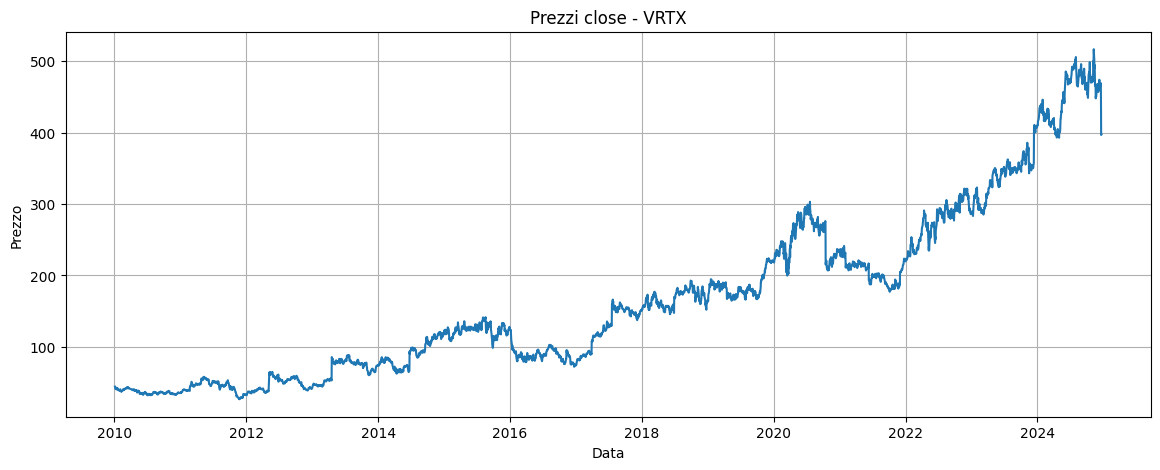

In [22]:
import matplotlib.pyplot as plt

ticker = "VRTX"

plt.figure(figsize=(14,5))
plt.plot(df_filled.index, df_filled[ticker])
plt.title(f"Prezzi close - {ticker}")
plt.xlabel("Data")
plt.ylabel("Prezzo")
plt.grid(True)
plt.show()

Guardando su Google la serie dei prezzi, i jump sembrano corretti.

Guardo la serie dei log-rendimenti.

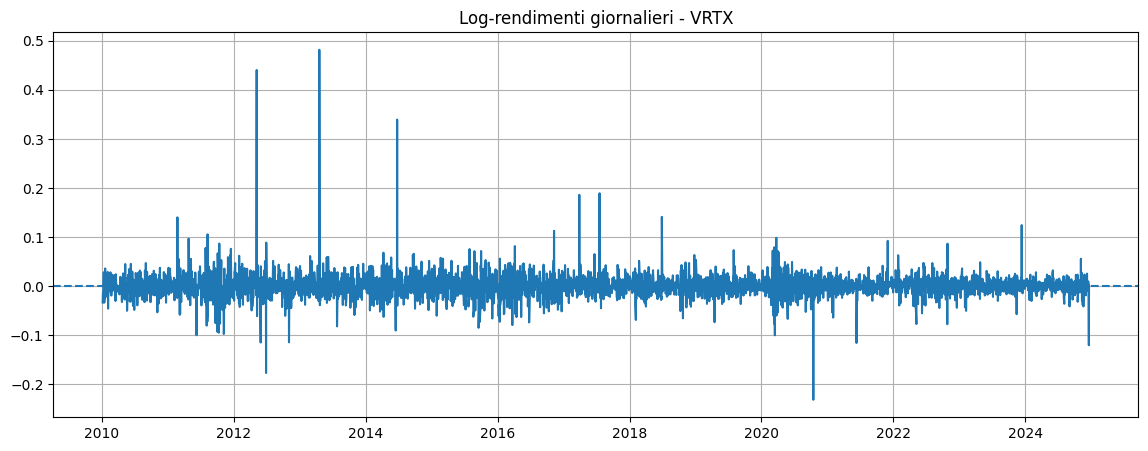

In [23]:
plt.figure(figsize=(14,5))
plt.plot(log_returns.index, log_returns[ticker])
plt.axhline(0, linestyle="--")
plt.title(f"Log-rendimenti giornalieri - {ticker}")
plt.grid(True)
plt.show()

Evidenzio gli outlier (|z_score| > 5) con dei marker 

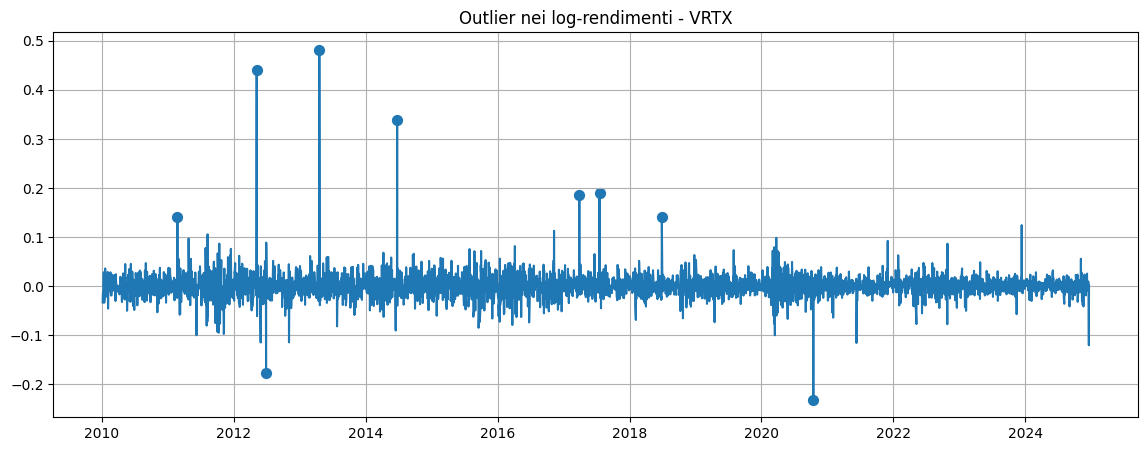

In [24]:
series = log_returns[ticker]

z = (series - series.mean()) / series.std()

outliers = np.abs(z) > 5

plt.figure(figsize=(14,5))

plt.plot(series.index, series.values)
plt.scatter(
    series.index[outliers],
    series[outliers],
    s=50
)

plt.title(f"Outlier nei log-rendimenti - {ticker}")
plt.grid(True)
plt.show()

In [25]:
# massimo log-return assoluto per ticker
max_abs_ret = log_returns.abs().max()

# ticker più estremi
max_abs_ret.sort_values(ascending=False).head(5)

DXCM    0.521858
BLDR    0.516894
VRTX    0.481849
NFLX    0.432578
WMB     0.427911
dtype: float64

Grafico i log-return delle equity che hanno i maggiori spike o drop.

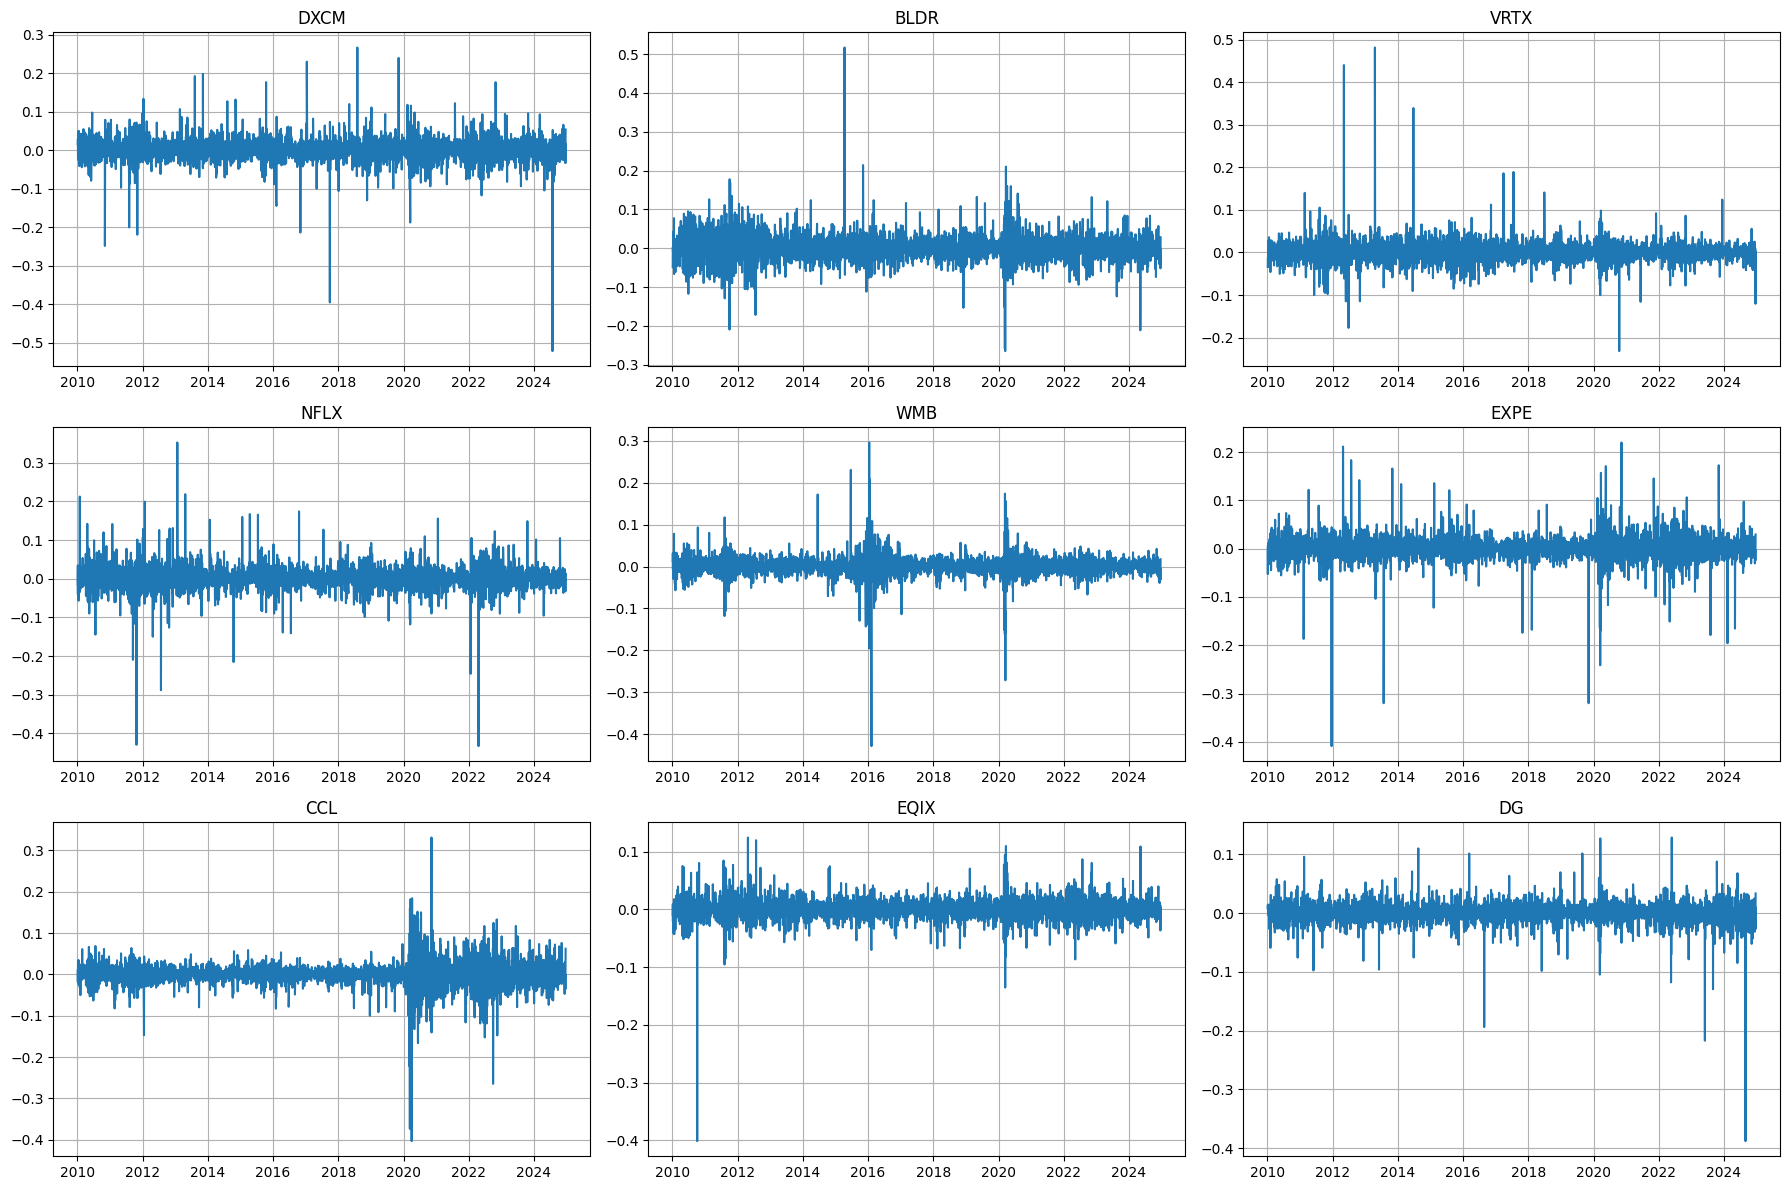

In [26]:
top_tickers = max_abs_ret.sort_values(ascending=False).head(9).index

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for ax, ticker in zip(axes.flatten(), top_tickers):
    ax.plot(log_returns.index, log_returns[ticker])
    ax.set_title(ticker)
    ax.grid(True)

plt.tight_layout()
plt.show()

# ASSUNZIONE: assumiamo che i prezzi siano non close, ma adjusted close, cioè che si tenga conto di split/dividendi
qualche controllo è stato fatto, ma qualche controllo aggiuntivo con altri data provider sarebbe utile

## Calcolo correlazioni di Pearson su finestre rolling di ampiezza W

In [27]:
# Ampiezza della finestra rolling
W = 252 # 1 anno

# Lista che conterrà le matrici di correlazione
rolling_corrs = []

# Lista delle date associate alla fine di ciascuna finestra
rolling_dates = []

# Numero totale di osservazioni
T = len(log_returns)

# Costruzione delle matrici rolling
for end_idx in range(W, T + 1):

    # Finestra corrente
    window = log_returns.iloc[end_idx - W:end_idx]

    # Matrice di correlazione di Pearson
    corr_matrix = window.corr(method="pearson")

    # Salvataggio
    rolling_corrs.append(corr_matrix)

    # Data finale della finestra
    rolling_dates.append(log_returns.index[end_idx - 1])

# Controlli
print(f"Numero matrici rolling: {len(rolling_corrs)}")
print(f"Shape singola matrice: {rolling_corrs[0].shape}")

Numero matrici rolling: 3516
Shape singola matrice: (151, 151)


In [28]:
rolling_corrs[2812]

,ABT,ADM,AES,AJG,ALB,ALL,AMP,AMZN,ANSS,AOS,...,VRSK,VRTX,VTRS,WDC,WEC,WELL,WMB,WRB,WST,WTW
ABT,1.000000,0.036711,0.204195,0.289080,0.174421,0.045244,0.192948,0.185830,0.418743,0.206713,...,0.323402,0.264395,0.186317,0.061790,0.260854,0.046015,-0.010195,0.146917,0.519774,0.171672
ADM,0.036711,1.000000,0.307721,0.313877,0.239663,0.480201,0.546861,0.038762,0.083987,0.378171,...,0.126013,0.159802,0.267331,0.306511,0.134616,0.308457,0.490308,0.465495,0.032799,0.267093
AES,0.204195,0.307721,1.000000,0.355233,0.405884,0.199575,0.443115,0.272711,0.397969,0.289929,...,0.259471,0.108935,0.098328,0.332531,0.193174,0.368245,0.276249,0.366475,0.231897,0.269655
AJG,0.289080,0.313877,0.355233,1.000000,0.354818,0.363238,0.496487,0.271671,0.451084,0.449953,...,0.421455,0.128219,0.155486,0.217923,0.211199,0.303420,0.236094,0.529369,0.343006,0.606430
ALB,0.174421,0.239663,0.405884,0.354818,1.000000,0.151976,0.547924,0.307869,0.515606,0.388251,...,0.215549,0.084412,0.193919,0.373684,-0.120955,0.201760,0.247666,0.270696,0.203258,0.203316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WELL,0.046015,0.308457,0.368245,0.303420,0.201760,0.326808,0.382944,0.154823,0.204155,0.286632,...,0.318600,0.137343,0.178723,0.281465,0.295151,1.000000,0.334452,0.427459,0.014329,0.278309
WMB,-0.010195,0.490308,0.276249,0.236094,0.247666,0.356318,0.429825,0.085700,0.045496,0.219834,...,0.035329,0.094101,0.185274,0.306297,0.039348,0.334452,1.000000,0.342658,-0.101333,0.180463
WRB,0.146917,0.465495,0.366475,0.529369,0.270696,0.637238,0.595054,0.062203,0.172911,0.453783,...,0.327666,0.091118,0.288727,0.270368,0.300749,0.427459,0.342658,1.000000,0.044460,0.368663
WST,0.519774,0.032799,0.231897,0.343006,0.203258,0.003087,0.168470,0.308718,0.533555,0.268966,...,0.466924,0.145391,0.005637,0.081403,0.123762,0.014329,-0.101333,0.044460,1.000000,0.203510


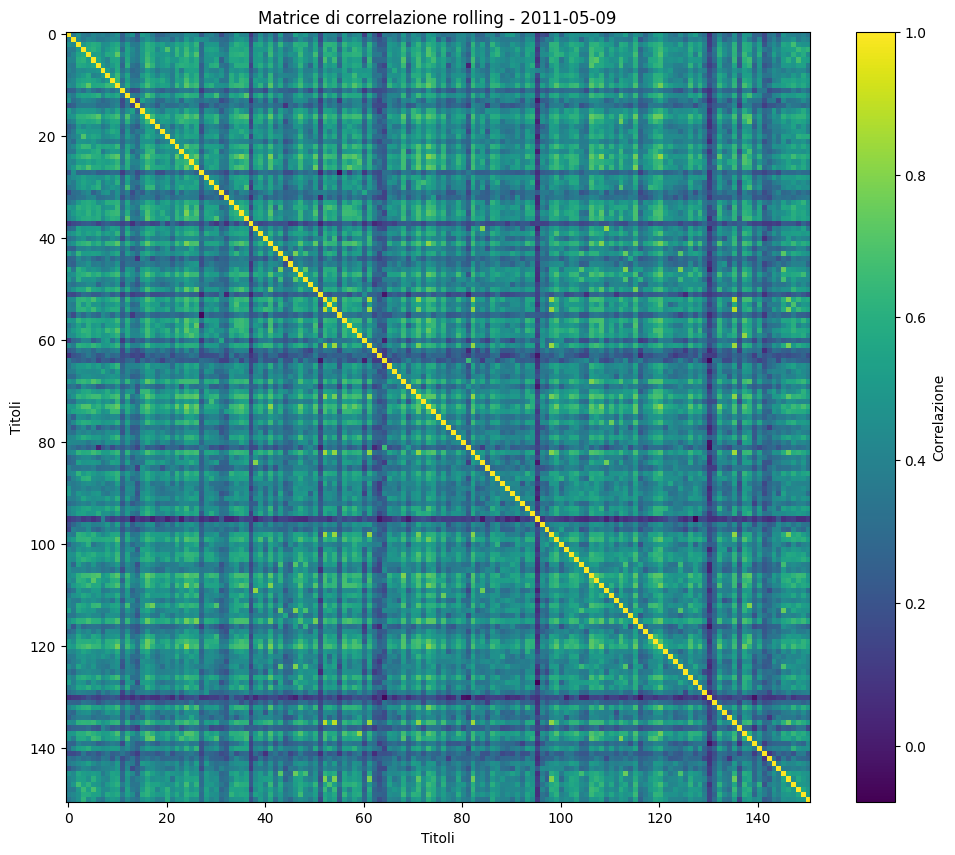

In [29]:
import matplotlib.pyplot as plt

# Indice della matrice rolling da visualizzare
idx = 87

corr_matrix = rolling_corrs[idx]

plt.figure(figsize=(12, 10))

plt.imshow(corr_matrix, aspect='auto')

plt.colorbar(label="Correlazione")

plt.title(f"Matrice di correlazione rolling - {rolling_dates[idx].date()}")

plt.xlabel("Titoli")
plt.ylabel("Titoli")

plt.show()

L’obiettivo è riordinare righe e colonne della matrice di correlazione in modo che i titoli “simili” tra loro vengano messi vicini.
Questo permette di far emergere visivamente:

gruppi settoriali,
cluster di titoli molto correlati,
strutture fattoriali del mercato.

L’idea è:

trasformare la correlazione in una distanza;
fare clustering gerarchico;
usare l’ordine delle foglie del dendrogramma per riordinare la matrice.

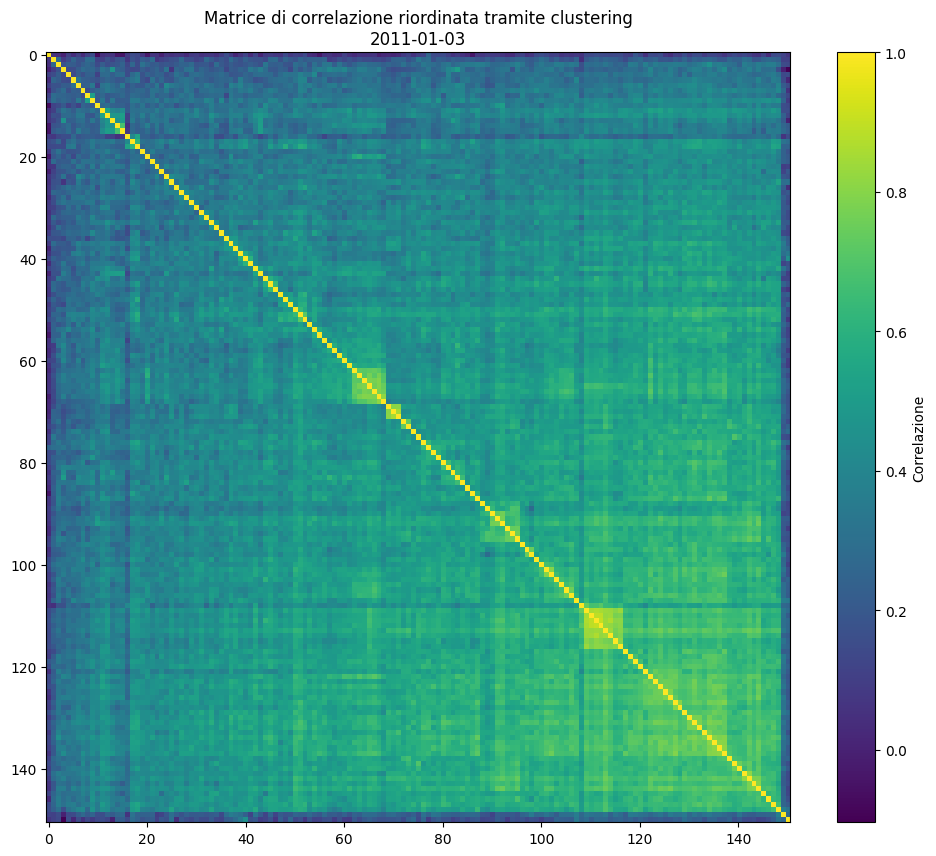

In [30]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# Selezioniamo una matrice rolling
idx = 0
corr_matrix = rolling_corrs[idx]

# Trasformiamo la correlazione in distanza
# correlazione alta -> distanza piccola
distance_matrix = 1 - corr_matrix

# squareform richiede diagonale nulla
np.fill_diagonal(distance_matrix.values, 0)

# Clustering gerarchico
linkage_matrix = linkage(
    squareform(distance_matrix.values),
    method='average'
)

# Ordine ottimale dei titoli
ordered_idx = leaves_list(linkage_matrix)

# Riordino della matrice
corr_ordered = corr_matrix.iloc[ordered_idx, ordered_idx]

# Plot
plt.figure(figsize=(12, 10))

plt.imshow(corr_ordered, aspect='auto')

plt.colorbar(label="Correlazione")

plt.title(
    f"Matrice di correlazione riordinata tramite clustering\n"
    f"{rolling_dates[idx].date()}"
)

plt.show()

Evoluzione temporale della correlazione media (media degli elementi fuori diagonale e contati una sola volta).

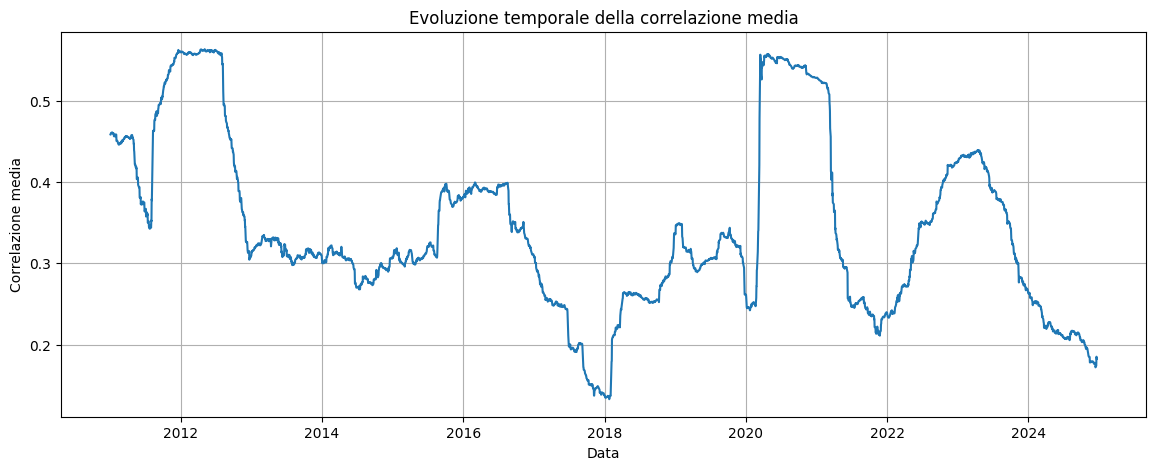

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Correlazione media di ciascuna matrice rolling
avg_corrs = []

for corr_matrix in rolling_corrs:

    # Estraiamo solo il triangolo superiore senza diagonale
    upper = corr_matrix.values[
        np.triu_indices_from(corr_matrix, k=1)
    ]

    avg_corrs.append(np.mean(upper))

# Serie temporale
avg_corrs = pd.Series(avg_corrs, index=rolling_dates)

# Plot
plt.figure(figsize=(14, 5))

plt.plot(avg_corrs.index, avg_corrs.values)

plt.title("Evoluzione temporale della correlazione media")

plt.xlabel("Data")
plt.ylabel("Correlazione media")

plt.grid(True)

plt.show()

Studio la struttura fattoriale delle matrici di correlazione rolling attraverso i loro autovalori. Gli autovalori indicano quanta “varianza collettiva” viene spiegata dai diversi fattori:
il primo autovalore rappresenta spesso il fattore di mercato;
i successivi rappresentano fattori settoriali o specifici. Vogliamo quindi verificare se compaiono autovalori negativi (problemi numerici o non-PSD); capire quanti fattori servono per spiegare il 90% della varianza totale. Per una matrice di correlazione N×N: la somma degli autovalori vale N; qui N=151.

In [32]:
import numpy as np
import pandas as pd

# Numero di titoli
N = log_returns.shape[1]

# Liste dei risultati
min_eigenvalues = []
n_factors_90 = []

for corr_matrix in rolling_corrs:

    # Autovalori
    eigvals = np.linalg.eigvalsh(corr_matrix.values)

    # Ordine decrescente
    eigvals = np.sort(eigvals)[::-1]

    # Minimo autovalore
    min_eigenvalues.append(eigvals.min())

    # Varianza cumulata spiegata
    cumulative_variance = np.cumsum(eigvals) / eigvals.sum()

    # Numero minimo di fattori per spiegare il 90%
    k90 = np.searchsorted(cumulative_variance, 0.90) + 1

    n_factors_90.append(k90)

# Convertiamo in serie temporali
min_eigenvalues = pd.Series(min_eigenvalues, index=rolling_dates)

n_factors_90 = pd.Series(n_factors_90, index=rolling_dates)

# Statistiche sintetiche
print("Autovalore minimo:")
print(min_eigenvalues.describe())

print("\nNumero fattori per spiegare il 90%:")
print(n_factors_90.describe())

Autovalore minimo:
count    3516.000000
mean        0.015870
std         0.004707
min         0.004142
25%         0.013030
50%         0.015978
75%         0.018949
max         0.027746
dtype: float64

Numero fattori per spiegare il 90%:
count    3516.000000
mean       62.584755
std         9.071578
min        36.000000
25%        60.000000
50%        64.000000
75%        70.000000
max        76.000000
dtype: float64


Visualizziamo l'evoluzione temporale del minimo autovalore (dovrebbe essere sempre >0, per PSD) e del numero di autovalori che catturano il 90% della varianza. Quest'ultimo più c'è crisi, più è basso, tipicamente.

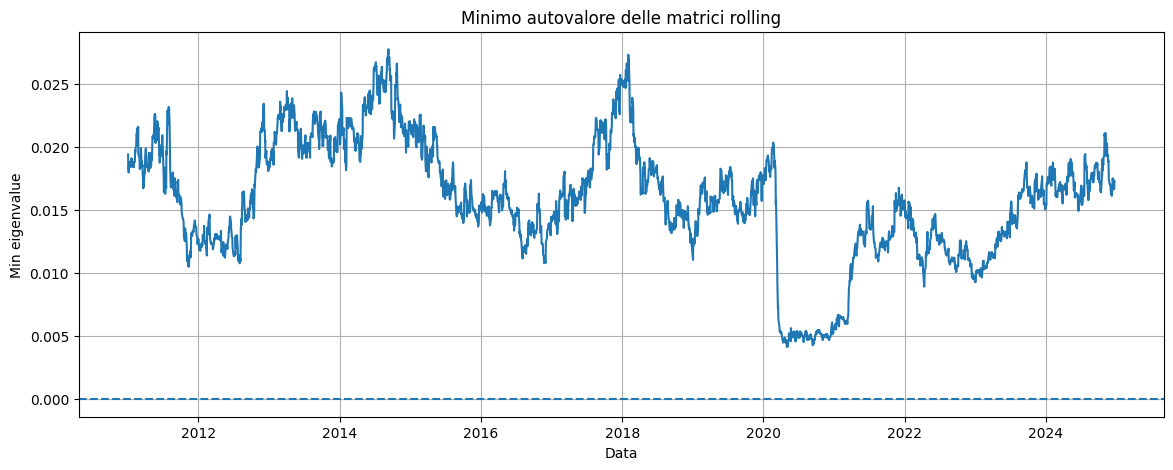

In [33]:
# Evoluzione del minimo autovalore

plt.figure(figsize=(14, 5))

plt.plot(min_eigenvalues.index, min_eigenvalues.values)

plt.axhline(0, linestyle='--')

plt.title("Minimo autovalore delle matrici rolling")

plt.xlabel("Data")
plt.ylabel("Min eigenvalue")

plt.grid(True)

plt.show()

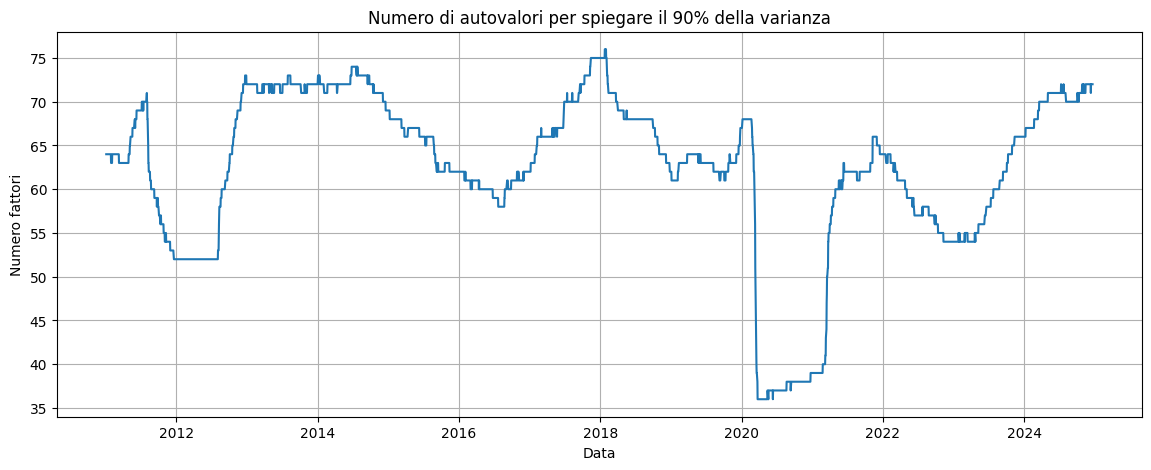

In [34]:
# Evoluzione del numero di fattori necessari
# per spiegare il 90% della varianza

plt.figure(figsize=(14, 5))

plt.plot(n_factors_90.index, n_factors_90.values)

plt.title("Numero di autovalori per spiegare il 90% della varianza")

plt.xlabel("Data")
plt.ylabel("Numero fattori")

plt.grid(True)

plt.show()

Ripeto il controllo della proprietà PSD (anche se è già garantita da autovalori tutti > 0).

In [35]:
import numpy as np
import pandas as pd

# Tolleranza numerica
tol = 1e-10

# Risultati
is_psd_list = []
min_eigvals = []

for corr_matrix in rolling_corrs:

    # Autovalori simmetrici
    eigvals = np.linalg.eigvalsh(corr_matrix.values)

    min_eig = eigvals.min()

    min_eigvals.append(min_eig)

    # PSD se tutti gli autovalori >= -tol
    is_psd = min_eig >= -tol

    is_psd_list.append(is_psd)

# Serie temporali
is_psd_series = pd.Series(is_psd_list, index=rolling_dates)

min_eigvals = pd.Series(min_eigvals, index=rolling_dates)

# Conteggio matrici non PSD
n_non_psd = (~is_psd_series).sum()

print(f"Numero matrici non PSD: {n_non_psd}")
print(f"Numero matrici PSD: {is_psd_series.sum()}")

print("\nMinimo autovalore osservato:")
print(min_eigvals.min())

Numero matrici non PSD: 0
Numero matrici PSD: 3516

Minimo autovalore osservato:
0.004141985754118652


In [36]:
# Date delle matrici non PSD
problem_dates = is_psd_series[~is_psd_series]

print(problem_dates)

Series([], dtype: bool)


In [37]:
# Peggiori autovalori minimi ("peggiori" nel senso della PSD)
min_eigvals.sort_values().head(5)

2020-05-01    0.004142
2020-05-05    0.004174
2020-05-04    0.004228
2020-05-06    0.004262
2020-09-11    0.004285
dtype: float64

#### Se qualche matrice non fosse PSD (cosa che può succedere con dati mancanti o errati negli input) si potrebbe utilizzare l'algoritmo di Higham.

Riduco la frequenza temporale delle matrici rolling per alleggerire memoria, tempo computazionale, PCA/AE successivi, analisi dinamiche.
Invece di costruire una matrice per ogni giorno, ne teniamo una ogni 21 giorni di mercato. Le finestre rolling restano di ampiezza 252, ma vengono campionate più diradatamente nel tempo.

In [38]:
# Passo temporale tra una matrice e la successiva
step = 21 # un mese lavorativo

# Liste ridotte
rolling_corrs_sparse = []
rolling_dates_sparse = []

# Costruzione delle matrici rolling "diradate"
for end_idx in range(W, T + 1, step):

    # Finestra rolling corrente
    window = log_returns.iloc[end_idx - W:end_idx]

    # Correlazione di Pearson
    corr_matrix = window.corr(method="pearson")

    # Salvataggio
    rolling_corrs_sparse.append(corr_matrix)

    # Data finale della finestra
    rolling_dates_sparse.append(log_returns.index[end_idx - 1])

# Controlli
print(f"Numero matrici originali: {len(rolling_corrs)}")
print(f"Numero matrici diradate: {len(rolling_corrs_sparse)}")

Numero matrici originali: 3516
Numero matrici diradate: 168


In [39]:
len(rolling_corrs_sparse)

168

Nuovo check che siano semi-definite positive.

In [40]:
import numpy as np
import pandas as pd

tol = 1e-8

results = []

for i, M in enumerate(rolling_corrs_sparse):

    # verifica simmetria
    max_asymmetry = np.max(np.abs(M - M.T))
    is_symmetric = max_asymmetry < tol

    # autovalori
    eigvals = np.linalg.eigvalsh(M)
    min_eig = eigvals.min()

    is_psd = min_eig >= -tol

    results.append({
        "matrix_idx": i,
        "is_symmetric": is_symmetric,
        "max_asymmetry": max_asymmetry,
        "min_eigenvalue": min_eig,
        "is_psd": is_psd,
        "is_sdp": is_symmetric and is_psd
    })

df_check = pd.DataFrame(results)

display(df_check)

print(f"SDP matrices: {df_check['is_sdp'].sum()} / {len(df_check)}")

,matrix_idx,is_symmetric,max_asymmetry,min_eigenvalue,is_psd,is_sdp
0,0,True,0.0,0.019405,True,True
1,1,True,0.0,0.018400,True,True
2,2,True,0.0,0.018241,True,True
3,3,True,0.0,0.019862,True,True
4,4,True,0.0,0.019103,True,True
...,...,...,...,...,...,...
163,163,True,0.0,0.016651,True,True
164,164,True,0.0,0.018324,True,True
165,165,True,0.0,0.016493,True,True
166,166,True,0.0,0.020249,True,True


SDP matrices: 168 / 168


Confrontiamo quanto bene:

- la PCA, che è lineare (fatta non sui rendimenti in una time window di 1y, ma sulle correlazioni in tutto il time range disponibile)
- un Autoencoder, che è non lineare

riescano a comprimere e ricostruire le matrici di correlazione rolling. L’idea intuitiva è: ogni matrice di correlazione 151×151 rappresenta uno “stato del mercato”; vogliamo comprimere questi stati in uno spazio latente più piccolo; poi ricostruirli e confrontare l’errore di ricostruzione. La PCA può catturare solo strutture lineari. L’Autoencoder può invece apprendere strutture non lineari più complesse.

Le matrici sono simmetriche, quindi basta usare il triangolo superiore.

Questo riduce molto la dimensionalità:

150×151/2=11325

feature per matrice.

In [41]:
N

151

In [42]:
# 
# trasformare ogni matrice di correlazione in un vettore,
# usando solo il triangolo superiore.

import numpy as np

# Indici del triangolo superiore
triu_idx = np.triu_indices(N, k=1) # N è il numero di titoli, con k=1 selezioniamo solo sopra la diagonale

# Dataset vettorializzato
X = np.array([
    corr.values[triu_idx]
    for corr in rolling_corrs_sparse
])

print("Shape dataset:", X.shape)

Shape dataset: (168, 11325)


In [43]:
# 
# fare scaling senza leakage temporale:
# fit sul training, transform su train e test.

from sklearn.preprocessing import StandardScaler

# Split temporale sui dati NON standardizzati
train_ratio = 0.8

split_idx = int(len(X) * train_ratio)

X_train_raw = X[:split_idx]
X_test_raw  = X[split_idx:]

# Fit scaler SOLO sul training set
# istanzio
scaler = StandardScaler() # per la PCA non ho bisogno dello scaler, basta la centratura che è fatta automaticamente

# chiamo il metodo fit_transform che calcola i parametri della standardizzazione, li include nell'oggetto "scaler" e li applica
X_train_std = scaler.fit_transform(X_train_raw) # <-- ogni COLONNA viene standardizzata

# applico il metodo transform dello stesso "scaler" al set di test
X_test_std = scaler.transform(X_test_raw)

# Controlli
print("Train shape:", X_train_std.shape)
print("Test shape: ", X_test_std.shape)

Train shape: (134, 11325)
Test shape:  (34, 11325)


## Standardizzazione (per AE) e split temporale train/test.

La standardizzazione è fatta solo sul training, per non usare nel training informazione del test.

## NB separariamo training e test rispettando l’ordine temporale delle matrici rolling.
Questo perché finestre vicine sono fortemente dipendenti; uno split random “contamina” il test con informazione quasi identica al training; il test error risulta artificialmente troppo ottimistico.

Con lo split temporale il modello viene addestrato sul passato e testato sul futuro.

# PCA delle correlazioni

## NB facciamo la PCA delle correlazioni storiche in tutto il range temporale disponibile, non la PCA dei rendimenti in una singola time window.

## Quindi lavoriamo sulla matrice di correlazione tra le correlazioni, non su una delle matrici di correlazione tra i rendimenti.

In [44]:
latent_dim = 36 # era il numero minimo nella storia di autovalori che spiegano il 90% della varianza

In [45]:
# 
# comprimere e ricostruire le matrici tramite PCA.

from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
# istanzio un oggetto che fa PCA e tieni solo latent_dim dimensioni
pca = PCA(n_components=latent_dim)
# faccio la PCA delle correlazioni storiche: calcola gli autovettori della serie storica di correlazioni, ne tiene 36, li moltiplica per le correlazioni storiche (standardizzate), ottenendo per ogni matrice di correlazione storica (cioè ogni riga di X_train_std) una rappresentazione non con 11325 numeri (151*150/2) ma con soli 36 numeri
Z_train_pca = pca.fit_transform(X_train_raw) # compressione (fa anche il centering)
X_train_rec_pca = pca.inverse_transform(Z_train_pca) # ricostruzione
Z_test_pca = pca.transform(X_test_raw) # compressione
X_test_rec_pca = pca.inverse_transform(Z_test_pca) # ricostruzione



# Errori: siccome poi voglio fare il confronto grafico con le calibrazioni degli Autoencoder, passo a corr. standardizzate
pca_train_mse = mean_squared_error(
    scaler.transform(X_train_raw),
    scaler.transform(X_train_rec_pca)
)
pca_test_mse = mean_squared_error(
    scaler.transform(X_test_raw),
    scaler.transform(X_test_rec_pca)
)
print(X_train_raw.shape)
print(Z_train_pca.shape)
print("PCA train MSE:", pca_train_mse)
print("PCA test  MSE:", pca_test_mse)

(134, 11325)
(134, 36)
PCA train MSE: 0.010253528849414629
PCA test  MSE: 0.4782852836794561


# PCA dei rendimenti
## su ogni singola matrice di correlazione tra rendimenti
## rappresentazione troncata di rango K=36 (usando k autovettori)
## della matrice di correlazione tra rendimenti

In [46]:
k = latent_dim

# per la PCA dei rendimenti lavoro con le matrici di correlazione, non c'è bisogno di centratura, erano i rendimenti a dover essere centrati

# ============================================
# Ricavo N dalla lunghezza del triangolo
# superiore senza diagonale
#
# m = N(N-1)/2
# ============================================
m = X_train_raw.shape[1]
N = int((1 + np.sqrt(1 + 8 * m)) / 2)
print("N =", N)
# Indici triangolo superiore senza diagonale
triu_idx = np.triu_indices(N, k=1)
# ============================================
# Array ricostruito
# ============================================
X_train_rec_returnsPCA = np.zeros_like(X_train_raw)
# ============================================
# Loop sulle matrici
# ============================================
for i in range(X_train_raw.shape[0]):
    # ----------------------------------------
    # Ricostruzione matrice di correlazione
    # ----------------------------------------
    corr = np.eye(N)
    corr[triu_idx] = X_train_raw[i]
    # simmetrizzazione
    corr[(triu_idx[1], triu_idx[0])] = X_train_raw[i] # inverto righe e colonne per la triang. inf.
    # ----------------------------------------
    # Decomposizione spettrale
    # ----------------------------------------
    eigvals, eigvecs = np.linalg.eigh(corr)
    # Ordino in ordine decrescente
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    # ----------------------------------------
    # Tengo solo i primi k autovettori
    # ----------------------------------------
    eigvals_k = eigvals[:k]
    eigvecs_k = eigvecs[:, :k]
    # ----------------------------------------
    # Ricostruzione rank-k
    # ----------------------------------------
    corr_rec = (
        eigvecs_k
        @ np.diag(eigvals_k)
        @ eigvecs_k.T
    )
#    # ----------------------------------------
#    # Rinormalizzazione -> matrice di correlazione
#    # ----------------------------------------
#    
#    std = np.sqrt(np.diag(corr_rec))
#    
#    corr_rec = corr_rec / np.outer(std, std)
#    
#    # opzionale: forza simmetria numerica
#    corr_rec = (corr_rec + corr_rec.T) / 2
    # ----------------------------------------
    # Estraggo triangolo superiore
    # ----------------------------------------
    X_train_rec_returnsPCA[i] = corr_rec[triu_idx]

# NB: la diagonale non sarà 1, non è una vera matr. di correlazione, però è la matrice PSD di rango k più vicina alla matrice di correlazione in input

# ============================================
# MSE finale
# ============================================
# SICCOME POI VOGLIO FARE IL GRAFICO CON GLI MSE DEGLI AUTOENCODER, PASSO A CORRELAZIONI STANDARDIZZATE
mse_returnsPCA = mean_squared_error(
    scaler.transform(X_train_raw),
    scaler.transform(X_train_rec_returnsPCA)
)
print("MSE =", mse_returnsPCA)

N = 151
MSE = 0.019721558629257546


# Autoencoder: addestriamo un AE fully connected per comprimere ciascuna matrice di correlazione storica da 11325 a 36 dimensioni e ricostruirla, sul train set. Poi vediamo come vengono ricostruite la matrici del test set, usando la stessa struttura dell'AE.

In [47]:
# 
# comprimere e ricostruire le matrici con un Autoencoder non lineare.

import tensorflow as tf
from tensorflow.keras import layers, Model

input_dim = X_train_std.shape[1]

# Encoder
encoder_input = layers.Input(shape=(input_dim,))

x = layers.Dense(512, activation='relu')(encoder_input)
x = layers.Dense(128, activation='relu')(x)

latent = layers.Dense(latent_dim, activation='linear')(x)

# Decoder
x = layers.Dense(128, activation='relu')(latent)
x = layers.Dense(512, activation='relu')(x)

decoder_output = layers.Dense(input_dim)(x)

# Modello
autoencoder = Model(encoder_input, decoder_output)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.summary()

I0000 00:00:1781042583.631702 2970371 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781042583.685557 2970371 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781042589.372471 2970371 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
E0000 00:00:1781042591.113777 2970371 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuIn

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 11325)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     5,798,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 36)             │         4,644 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11325)          │     5,809,725 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,749,729 (44.82 MB)

 Trainable params: 11,749,729 (44.82 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr_AE = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.8,
    patience=20,
    min_lr=1e-6
)

Training

In [49]:
# 
# addestrare l'Autoencoder a ricostruire le matrici.

AE_history = autoencoder.fit(
    X_train_std, # input dato alla rete
    X_train_std, # target della rete
    validation_data=(X_test_std, X_test_std), # dati NON usati per il training (per overfitting e generalizzazione)
    epochs=400,
    batch_size=32,
    verbose=1,
    callbacks=[reduce_lr_AE]
)

Epoch 1/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.9989 - val_loss: 0.8607 - learning_rate: 0.0010
Epoch 2/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.5627 - val_loss: 0.7894 - learning_rate: 0.0010
Epoch 3/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.4681 - val_loss: 0.7735 - learning_rate: 0.0010
Epoch 4/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.4126 - val_loss: 0.7415 - learning_rate: 0.0010
Epoch 5/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.3272 - val_loss: 0.7124 - learning_rate: 0.0010
Epoch 6/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2556 - val_loss: 0.7120 - learning_rate: 0.0010
Epoch 7/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2285 - val_loss: 0.7012 - learning_rate: 0.0010
Epoch 8/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1930 - val_loss: 0.7206 - learning_rate: 0.0010
Epoch 9/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1650 - val_loss: 0.7058 - learning_rate: 0.0010
Epoch 10/400
5/5 ━━━━━━━━━━━

# Autoencoder lineare

In [50]:
import tensorflow as tf
from tensorflow.keras import layers, Model

input_dim = X_train_std.shape[1]

# =========================
# Encoder lineare
# =========================

encoder_input = layers.Input(shape=(input_dim,))

# Encoder
latent = layers.Dense(latent_dim, activation='linear', use_bias=False)(encoder_input)

# Decoder
decoder_output = layers.Dense(input_dim, activation='linear', use_bias=False)(latent)

autoencoder_linear = Model(encoder_input, decoder_output)

autoencoder_linear.compile(optimizer="adam", loss='mse')

autoencoder_linear.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 11325)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 36)             │       407,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 11325)          │       407,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 815,400 (3.11 MB)

 Trainable params: 815,400 (3.11 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
reduce_lr_linAE = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.8,
    patience=20,
    min_lr=1e-6
)

In [52]:
# 
# addestrare l'Autoencoder lineare a ricostruire le matrici.

linAE_history = autoencoder_linear.fit(
    X_train_std, # input dato alla rete
    X_train_std, # target della rete
    validation_data=(X_test_std, X_test_std), # dati NON usati per il training (per overfitting e generalizzazione)
    epochs=400,
    batch_size=32,
    verbose=1,
    callbacks=[reduce_lr_linAE]
)

Epoch 1/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.1901 - val_loss: 1.3829 - learning_rate: 0.0010
Epoch 2/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9417 - val_loss: 0.8415 - learning_rate: 0.0010
Epoch 3/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5087 - val_loss: 0.7785 - learning_rate: 0.0010
Epoch 4/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4508 - val_loss: 0.7448 - learning_rate: 0.0010
Epoch 5/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4065 - val_loss: 0.7342 - learning_rate: 0.0010
Epoch 6/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3605 - val_loss: 0.7213 - learning_rate: 0.0010
Epoch 7/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3126 - val_loss: 0.7004 - learning_rate: 0.0010
Epoch 8/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2734 - val_loss: 0.6833 - learning_rate: 0.0010
Epoch 9/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2445 - val_loss: 0.6824 - learning_rate: 0.0010
Epoch 10/400
5/5 ━━━━━━━━━━━

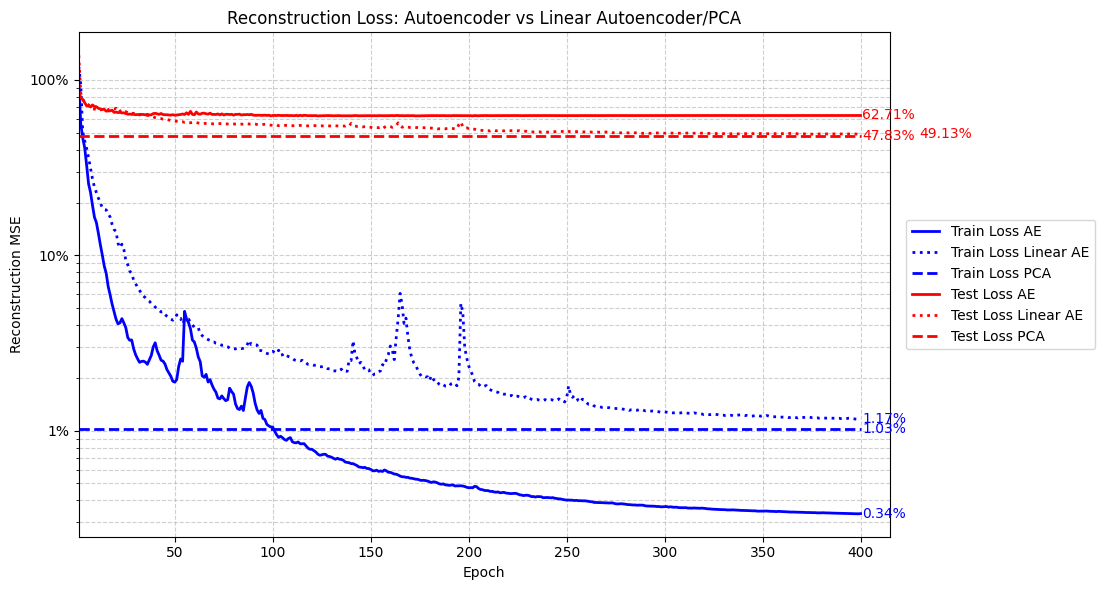

In [53]:
from matplotlib.ticker import PercentFormatter, ScalarFormatter
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

train_loss = AE_history.history["loss"]
test_loss = AE_history.history["val_loss"]

linAE_train_loss = linAE_history.history["loss"]
linAE_test_loss = linAE_history.history["val_loss"]

epochs = range(1, len(train_loss) + 1)

# =========================
# TRAIN LOSSES (blue)
# =========================

# AE
plt.plot(epochs, train_loss, color="blue", linestyle="-", linewidth=2, label="Train Loss AE")

# Linear AE
plt.plot(epochs, linAE_train_loss, color="blue", linestyle=":", linewidth=2, label="Train Loss Linear AE")

# PCA
plt.hlines(y=pca_train_mse, xmin=1, xmax=400, colors="blue", linestyles="--", linewidth=2, label="Train Loss PCA")

# =========================
# TEST LOSSES (red)
# =========================

# AE
plt.plot(epochs, test_loss, color="red", linestyle="-", linewidth=2, label="Test Loss AE")

# Linear AE
plt.plot(epochs, linAE_test_loss, color="red", linestyle=":", linewidth=2, label="Test Loss Linear AE")

# PCA
plt.hlines(y=pca_test_mse, xmin=1, xmax=400, colors="red", linestyles="--", linewidth=2, label="Test Loss PCA")

# =========================
# RETURNS PCA (green)
# =========================

#plt.hlines(y=mse_returnsPCA, xmin=1, xmax=400, colors="green", linestyles="-.", linewidth=2, label="Train Loss PCA on returns")

# =========================
# LABELS AT CURVE ENDS
# =========================

last_epoch = epochs[-1]

plt.text(last_epoch + 1, train_loss[-1], f"{train_loss[-1]:.2%}", color="blue", va="center")
plt.text(last_epoch + 1, linAE_train_loss[-1], f"{linAE_train_loss[-1]:.2%}", color="blue", va="center")
plt.text(401, pca_train_mse, f"{pca_train_mse:.2%}", color="blue", va="center")

plt.text(last_epoch + 1, test_loss[-1], f"{test_loss[-1]:.2%}", color="red", va="center")
plt.text(last_epoch + 30, linAE_test_loss[-1], f"{linAE_test_loss[-1]:.2%}", color="red", va="center")
plt.text(401, pca_test_mse, f"{pca_test_mse:.2%}", color="red", va="center")

#plt.text(401, mse_returnsPCA, f"{mse_returnsPCA:.2%}", color="green", va="center")

# =========================
# LOG SCALE
# =========================
plt.yscale("log")

# Percentage formatting
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

# Layout
plt.xlabel("Epoch")
plt.ylabel("Reconstruction MSE")
plt.title("Reconstruction Loss: Autoencoder vs Linear Autoencoder/PCA")

plt.grid(True, which="both", linestyle="--", alpha=0.6)

# Legend outside plot
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

# Leave space for labels and legend
plt.xlim(1, last_epoch + 15)

# Leave space for legend
plt.tight_layout(rect=[0, 0, 0.80, 1])

plt.show()

Ricostruzione Autoencoder

In [54]:
X_train_std.shape

(134, 11325)

In [55]:
X_test_std.shape

(34, 11325)

In [56]:
# 
# confrontare l'errore di ricostruzione dell'AE
# con quello della PCA.

X_train_rec_ae = autoencoder.predict(X_train_std)
X_train_rec_ae.shape

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


(134, 11325)

In [57]:
X_test_rec_ae = autoencoder.predict(X_test_std)
X_test_rec_ae.shape

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


(34, 11325)

In [58]:
ae_train_mse = mean_squared_error(X_train_std, X_train_rec_ae)

ae_test_mse = mean_squared_error(X_test_std, X_test_rec_ae)

In [59]:
X_train_rec_linae = autoencoder_linear.predict(X_train_std)
X_test_rec_linae = autoencoder_linear.predict(X_test_std)

linae_train_mse = mean_squared_error(X_train_std, X_train_rec_linae)
linae_test_mse = mean_squared_error(X_test_std, X_test_rec_linae)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [60]:
print("PCA train MSE:", pca_train_mse)
print("PCA test  MSE:", pca_test_mse)
print("AE train MSE:", ae_train_mse)
print("AE test  MSE:", ae_test_mse)
print("linear AE train MSE:", linae_train_mse)
print("linear AE test  MSE:", linae_test_mse)

PCA train MSE: 0.010253528849414629
PCA test  MSE: 0.4782852836794561
AE train MSE: 0.0033516375868387215
AE test  MSE: 0.6271445720613783
linear AE train MSE: 0.011571777922632644
linear AE test  MSE: 0.4913490633826189


Il numero di elementi da riprodurre è 1'902'600 (= 168 matrici * 151 stock * 150 / 2)

Il numero di gradi di libertà è molto diverso:

PCA: 6'048 (= 168 matrici * 36 autovettori)

AE: 11'749'729

linear AE: 815'400

GDL_AE / GDL_PCA = 2000

GDL_linAE / GDL_PCA = 135

## L'AE, che è avvantaggiato da tanti GDL e dalla nonlinearità, performa leggermente meglio in-sample, ma di molto poco

## Il gap train/test è enorme per tutte le compressioni (PCA, linear AE, AE)
Le tre compressioni soffrono il regime shift andando "nel futuro" (quindi il mercato non è stazionario), ma l’AE soffre più della PCA (cioè generalizza peggio OOT).

Sul training set la nonlinearità dell'AE dà vantaggi molto piccoli; sul testing set l'AE generalizza peggio della PCA.

Si può dire che una PCA globale apprende un sottospazio medio del passato, un AE globale apprende una manifold media del passato, ma il futuro può vivere in una regione diversa dello spazio.

Confronto visivamente:

- la matrice originale,
- la ricostruzione PCA,
- la ricostruzione Autoencoder.

Per vedere intuitivamente quali strutture vengono preservate, quanto bene vengono ricostruiti i cluster, se le correlazioni forti vengono smussate, se emergono artefatti.

Poiché i modelli lavorano sui vettori del triangolo superiore, dobbiamo prima ricostruire le matrici simmetriche complete.

In [61]:
# 
# ricostruire una matrice simmetrica completa
# a partire dal vettore del triangolo superiore.

def vector_to_corr_matrix(vec, n):

    # Matrice identità (diagonale già a 1)
    M = np.eye(n)

    # Riempimento triangolo superiore
    upper_idx = np.triu_indices(n, k=1)
    M[upper_idx] = vec

    # Copia nel triangolo inferiore
    M[(upper_idx[1], upper_idx[0])] = vec

    return M

In [62]:
# 
# confrontare originale, PCA e AE
# sulla stessa matrice del test set.

# Indice esempio test
idx = 10

# Originale
x_true = X_test_std[idx]

# Ricostruzione PCA
x_pca = X_test_rec_pca[idx]
z
# Ricostruzione AE
x_ae = X_test_rec_ae[idx]

# Inversione scaling
x_true_unscaled = scaler.inverse_transform(
    x_true.reshape(1, -1)
).flatten()

x_pca_unscaled = scaler.inverse_transform(
    x_pca.reshape(1, -1)
).flatten()

x_ae_unscaled = scaler.inverse_transform(
    x_ae.reshape(1, -1)
).flatten()

In [63]:
x_ae_unscaled.shape

(11325,)

In [64]:
# Ricostruzione matrici
M_true = vector_to_corr_matrix(x_true_unscaled, N)

M_pca = vector_to_corr_matrix(x_pca_unscaled, N)

M_ae = vector_to_corr_matrix(x_ae_unscaled, N)

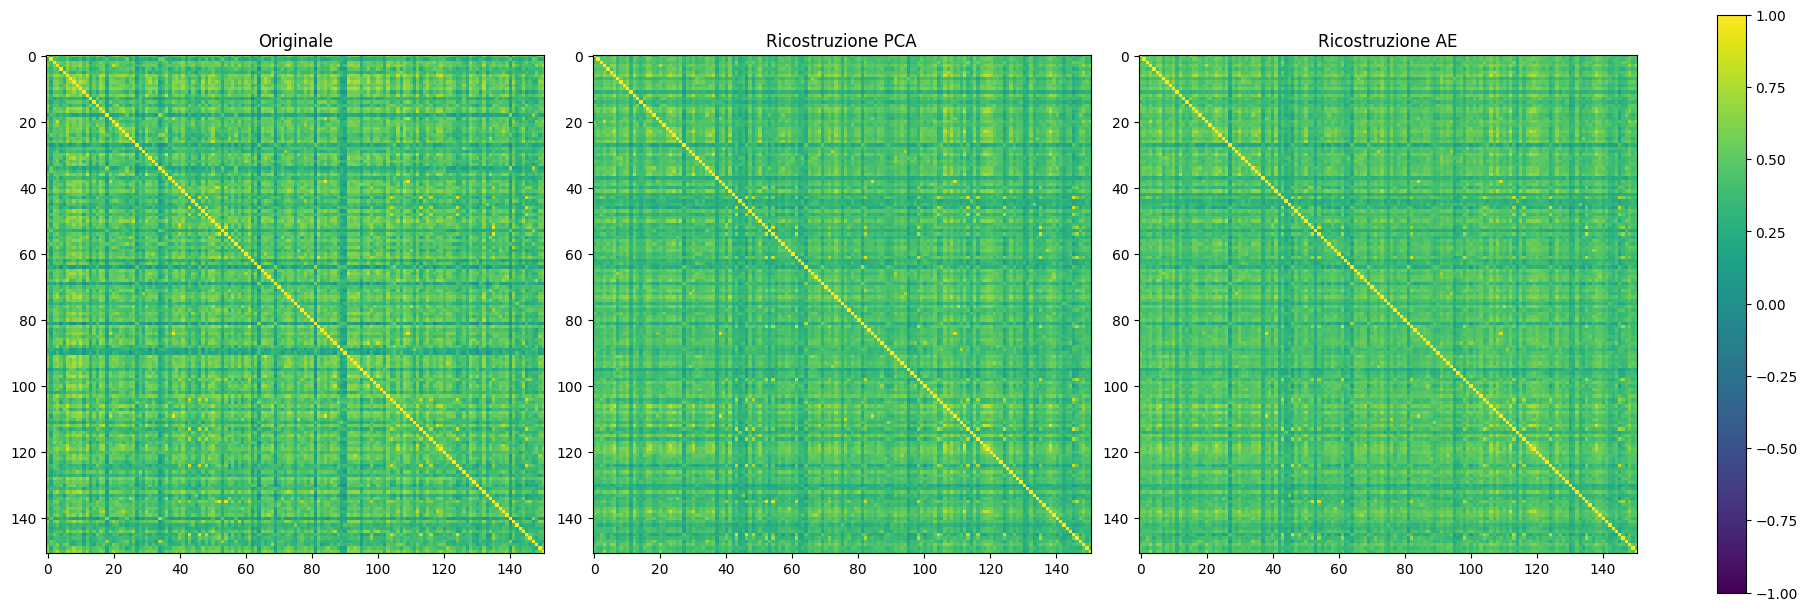

In [65]:
# visualizzo le tre matrici

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6),
    constrained_layout=True
)

# Originale
im0 = axes[0].imshow(M_true, vmin=-1, vmax=1)
axes[0].set_title("Originale")

# PCA
axes[1].imshow(M_pca, vmin=-1, vmax=1)
axes[1].set_title("Ricostruzione PCA")

# AE
axes[2].imshow(M_ae, vmin=-1, vmax=1)
axes[2].set_title("Ricostruzione AE")

# Colorbar comune
fig.colorbar(im0, ax=axes)

plt.show()

In [66]:
# 
# calcolo il reconstruction error della singola matrice
# visualizzata.

from sklearn.metrics import mean_squared_error

# MSE PCA
mse_pca_single = mean_squared_error(
    x_true_unscaled,
    x_pca_unscaled
)

# MSE AE
mse_ae_single = mean_squared_error(
    x_true_unscaled,
    x_ae_unscaled
)

print(f"MSE PCA: {mse_pca_single:.6f}")
print(f"MSE AE : {mse_ae_single:.6f}")

MSE PCA: 0.012348
MSE AE : 0.012356


## Spettro

In [67]:
# 
# calcolo gli autovalori delle tre matrici
# e verificare la proprietà PSD.

# Autovalori (ordinati decrescentemente)
eig_true = np.sort(np.linalg.eigvalsh(M_true))[::-1]

eig_pca = np.sort(np.linalg.eigvalsh(M_pca))[::-1]

eig_ae = np.sort(np.linalg.eigvalsh(M_ae))[::-1]

# Minimi autovalori
print("Min eigenvalue originale:", eig_true.min())
print("Min eigenvalue PCA       :", eig_pca.min())
print("Min eigenvalue AE        :", eig_ae.min())

# Controllo PSD
tol = 1e-10

print("\nPSD originale:", eig_true.min() >= -tol)
print("PSD PCA       :", eig_pca.min() >= -tol)
print("PSD AE        :", eig_ae.min() >= -tol)

Min eigenvalue originale: 0.010011771615846696
Min eigenvalue PCA       : 0.027124376822919412
Min eigenvalue AE        : 0.06145796675854512

PSD originale: True
PSD PCA       : True
PSD AE        : True


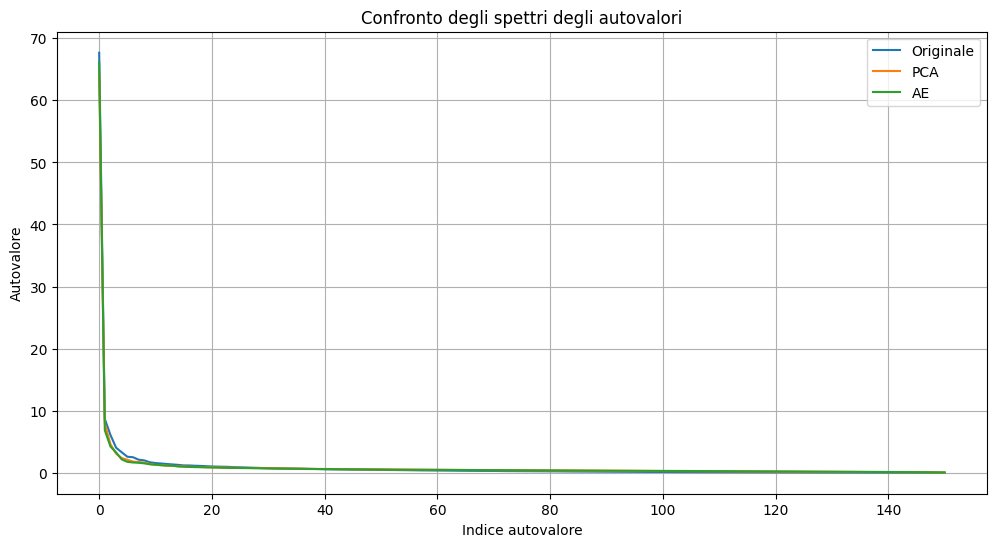

In [68]:
# 
# confrontare visivamente gli spettri degli autovalori.

plt.figure(figsize=(12, 6))
plt.plot(eig_true, label="Originale")
plt.plot(eig_pca, label="PCA")
plt.plot(eig_ae, label="AE")
plt.title("Confronto degli spettri degli autovalori")
plt.xlabel("Indice autovalore")
plt.ylabel("Autovalore")
plt.grid(True)
plt.legend()
plt.show()

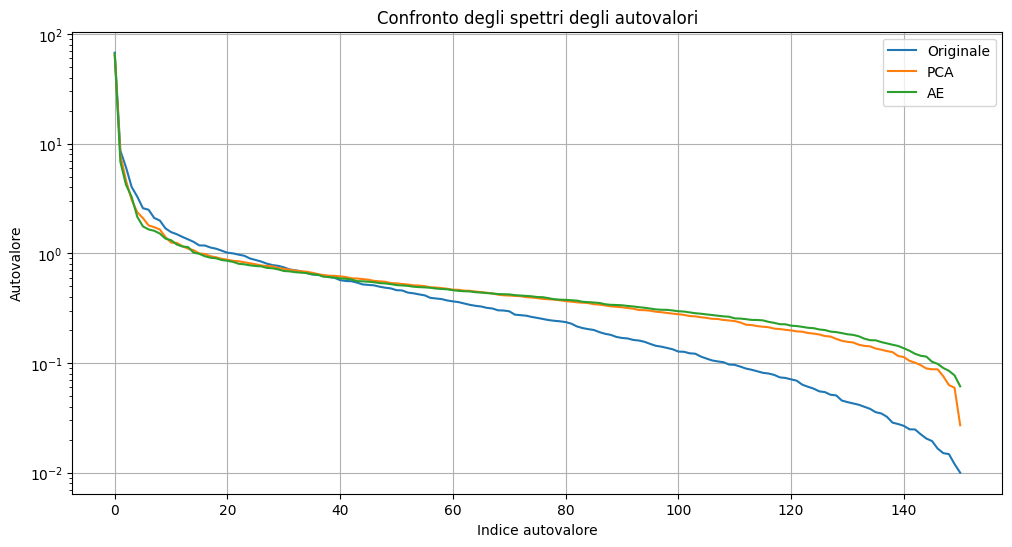

In [69]:
# 
# confrontare visivamente gli spettri degli autovalori in scala logaritmica

plt.figure(figsize=(12, 6))
plt.plot(eig_true, label="Originale")
plt.plot(eig_pca, label="PCA")
plt.plot(eig_ae, label="AE")
plt.title("Confronto degli spettri degli autovalori")
plt.xlabel("Indice autovalore")
plt.ylabel("Autovalore")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

# STOP
# Prova: parametrizzazione Positive Semi Definite nell'Autoencoder

### Visto che le matrici ricostruite da PCA ed AE in genere non sono PSD, facciamo lavorare la PCA e l'AE non in R^11325 ma nella varietà PSD dentro R^11325

## Passiamo a una parametrizzazione PSD-aware:
invece di far predire direttamente la matrice di correlazione C, facciamo predire una matrice triangolare inferiore L, e poi costruiamo:

LL^⊤

Per costruzione LL^⊤ è sempre simmetrica ed è sempre PSD. Per ottenere una vera correlation matrix costruisco S=LL^T e poi normalizzo.

In [70]:
# 
# trasformare ogni correlation matrix
# nel vettore del triangolo superiore.

import numpy as np

N = rolling_corrs_sparse[0].shape[0]

# Indici triangolo superiore
triu_idx = np.triu_indices(N, k=1)

# Dataset vettorizzato
X_corr = []

for corr_df in rolling_corrs_sparse:

    C = corr_df.values

    vec = C[triu_idx]

    X_corr.append(vec)

X_corr = np.array(X_corr)

print("Shape:", X_corr.shape)

Shape: (168, 11325)


In [71]:
assert X_corr.shape[1] == N * (N - 1) // 2

In [72]:
assert np.allclose(
    np.diag(rolling_corrs_sparse[0].values),
    1.0
)

In [73]:
# 
# split temporale.

train_ratio = 0.8

split_idx = int(len(X_corr) * train_ratio)

X_train = X_corr[:split_idx]

X_test = X_corr[split_idx:]

print(X_train.shape)
print(X_test.shape)

(134, 11325)
(34, 11325)


In [74]:
# 
# numero di elementi della Cholesky
n_triangular = N * (N + 1) // 2
n_triangular

11476

In [75]:
# Indici triangolo inferiore, compresa però la diagonale
tril_idx = np.tril_indices(N)
len(tril_idx[0])

11476

In [76]:
#
# funzione da applicare a un lotto di vettori prodotti in output
# per interpretarli come matrici di Cholesky e calcolare le corrispondenti matrici di corr
# Interpreta l'output del decoder come i coefficienti di una
# matrice triangolare inferiore L (nota: compresa la diagonale, Cholesky deve avercela)
#
# Da L costruisce:
#
#     S = L Lᵀ
#
# che è sempre simmetrica e semidefinita positiva (PSD).
#
# Successivamente normalizza S in modo che la diagonale diventi
# unitaria, ottenendo una vera matrice di correlazione:
#
#     C = D^{-1/2} S D^{-1/2}
#
# dove D contiene le varianze (la diagonale di S).
#
# Il risultato finale è quindi una matrice:
#
# - simmetrica
# - PSD
# - con diagonale pari a 1
#
# cioè una correlation matrix valida.
#

import tensorflow as tf

def build_correlation_matrix(x):

    #
    # x ha shape:
    #
    #     (batch_size, n_triangular)
    #
    # dove:
    #
    #     n_triangular = N(N+1)/2
    #
    # Ogni riga contiene i coefficienti necessari a riempire
    # il triangolo inferiore di una matrice N×N.
    #
    batch_size = tf.shape(x)[0]

    #
    # tril_idx è stato definito globalmente come:
    #
    #     np.tril_indices(N)
    #
    # e contiene le coordinate di tutti gli elementi del
    # triangolo inferiore (diagonale inclusa).
    #
    # Ad esempio per N=3:
    #
    #     [(0,0),
    #      (1,0),
    #      (1,1),
    #      (2,0),
    #      (2,1),
    #      (2,2)]
    #
    indices = np.array(
        list(zip(tril_idx[0], tril_idx[1]))
    )

    #
    # Conversione in tensore TensorFlow.
    #
    # Verrà utilizzato per inserire i coefficienti
    # nella matrice L.
    #
    indices_tf = tf.constant(
        indices,
        dtype=tf.int32
    )

    #
    # Individua quali posizioni del vettore corrispondono
    # agli elementi diagonali della matrice L.
    #
    # tril_idx[0] = indici di riga
    # tril_idx[1] = indici di colonna
    #
    # Sulla diagonale vale:
    #
    #     riga == colonna
    #
    diag_mask = tril_idx[0] == tril_idx[1]

    #
    # Posizioni nel vettore che corrispondono alla diagonale.
    #
    # Ad esempio:
    #
    #     [0, 2, 5, 9, ...]
    #
    diag_positions = np.where(diag_mask)[0]

    diag_positions_tf = tf.constant(
        diag_positions,
        dtype=tf.int32
    )

    #
    # Costruisce una singola matrice triangolare inferiore L
    # a partire da un vettore "sample".
    #
    def build_L(sample):

        #
        # Estrae dal vettore gli elementi che finiranno
        # sulla diagonale di L.
        #
        sample_diag = tf.gather(
            sample,
            diag_positions_tf
        )

        #
        # Forza la diagonale ad essere positiva.
        #
        # softplus(z) = log(1 + exp(z))
        #
        # è sempre > 0.
        #
        # Questo rende L una valida matrice di Cholesky.
        #
        sample_diag = tf.nn.softplus(sample_diag) # <- impone diagonale non nulla e garantisce unicità della parametrizzazione (altrimenti matrici di Cholesky che differiscono per il segno di una colonna darebbero la stess corrmatrix)

        #
        # Sostituisce nel vettore originale i valori
        # della diagonale con quelli trasformati.
        #
        sample = tf.tensor_scatter_nd_update(
            sample,
            tf.expand_dims(diag_positions_tf, axis=1),
            sample_diag
        )

        #
        # Costruisce una matrice N×N inizialmente nulla.
        #
        # Poi inserisce gli elementi del vettore sample
        # nelle posizioni del triangolo inferiore.
        #
        # Gli elementi sopra la diagonale restano zero.
        #
        # Si ottiene:
        #
        #     [ * 0 0 ]
        #     [ * * 0 ]
        #     [ * * * ]
        #
        L = tf.tensor_scatter_nd_update(
            tf.zeros((N, N), dtype=tf.float32),
            indices_tf,
            sample
        )

        return L

    #
    # Applica build_L a tutti gli elementi del batch.
    #
    # Input:
    #
    #     (batch_size, n_triangular)
    #
    # Output:
    #
    #     (batch_size, N, N)
    #
    L = tf.map_fn(build_L, x)

    #
    # Costruzione della matrice PSD.
    #
    # Per definizione:
    #
    #     S = L Lᵀ
    #
    # è sempre:
    #
    # - simmetrica
    # - definita positiva (grazie alla diagonale strettamente positiva)
    # può essere interpretata come una matrice di covarianza, dobbiamo poi passare alla matrice di correlazione
    #
    S = tf.matmul(L, L, transpose_b=True)

    #
    # Estrae la diagonale di S.
    #
    # Shape:
    #
    #     (batch_size, N)
    #
    diag = tf.linalg.diag_part(S)

    #
    # Costruisce:
    #
    #     D^{-1/2}
    #
    # con:
    #
    #     D = diag(S)
    #
    # L'epsilon evita problemi numerici
    # in caso di valori molto piccoli.
    #
    inv_std = tf.linalg.diag(
        1.0 / tf.sqrt(diag + 1e-8)
    )
    # inv_std contiene l'inverso delle deviazioni standard:
    #
    #     1 / sqrt(var_i)
    #
    # e serve a trasformare la matrice di covarianza
    # nella corrispondente matrice di correlazione.
    #
    # Trasformazione da matrice di covarianza
    # a matrice di correlazione.
    #
    # Formula:
    #
    #     C = D^{-1/2} S D^{-1/2}
    #
    # Questa operazione:
    #
    # - preserva la PSD
    # - mantiene la simmetria
    # - impone Cii = 1
    #
    C = tf.matmul(
        tf.matmul(inv_std, S),
        inv_std
    )

    #
    # Output:
    #
    #     (batch_size, N, N)
    #
    # contenente matrici di correlazione valide.
    #
    return C

In [77]:
# 
# funzione da applicare alle righe del tensore dato in input all'AE:
# ricostruisce la correlation matrix originale
# dal triangolo superiore.

def upper_to_corr_matrix(x):

#    batch_size = tf.shape(x)[0]

    indices = np.array(
        list(zip(triu_idx[0], triu_idx[1])) # triu_idx è definito globalmente, contiene gli indici degli elementi della matrice upper diagonal, senza la diagonale
    )

    indices_tf = tf.constant(
        indices,
        dtype=tf.int32
    )

    def build_matrix(sample):

        C = tf.tensor_scatter_nd_update(
            tf.zeros((N, N), dtype=tf.float32),
            indices_tf,
            sample
        )

        # Simmetrizzazione
        C = (
            C
            + tf.transpose(C)
            + tf.eye(N, dtype=tf.float32)
        )

        return C

    C = tf.map_fn(build_matrix, x)

    return C

In [78]:
X_train.shape

(134, 11325)

Do un lotto con le prime due matrici di correlazione in pasto a upper_to_corr_matrix per verificare che funzioni.

In [79]:
C_test = upper_to_corr_matrix(
    tf.constant(X_train[:2], dtype=tf.float32)
)

print(C_test.shape)

(2, 151, 151)


Verifico che siano state ricostruite le prime due matr. di corr. del nostro dataset.

In [80]:
np.allclose(
    C_test.numpy()[0],
    rolling_corrs_sparse[0].values
)

True

In [81]:
def correlation_loss(y_true, y_pred):

    C_true = upper_to_corr_matrix(y_true)
    
    C_pred = build_correlation_matrix(y_pred)
    
    return tf.reduce_mean(
        tf.square(C_true - C_pred)
    ) # media delle differenze al quadrato (cioè la Frobenius quadrata normalizzata)

In [82]:
#
# Costruire l'AE PSD-aware.
#

from tensorflow.keras import layers, Model

latent_dim = 10
input_dim = X_train.shape[1]

# --------------------------------------------------
# Encoder
# 11325 -> 1024 -> 256 -> 64 -> 10
# --------------------------------------------------

encoder_input = layers.Input(shape=(input_dim,))

x = layers.Dense(1024, activation='relu')(encoder_input)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)

latent = layers.Dense(latent_dim, name="latent")(x)

# --------------------------------------------------
# Decoder
# 10 -> 64 -> 256 -> 1024 -> 11476
# --------------------------------------------------

x = layers.Dense(64, activation='relu')(latent)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(1024, activation='relu')(x)

# Output = coefficienti del triangolo inferiore
# (compresa la diagonale)
decoder_output = layers.Dense(
    n_triangular,
    name="decoder_output"
)(x)

# --------------------------------------------------
# Autoencoder
# --------------------------------------------------

autoencoder = Model(
    encoder_input,
    decoder_output,
    name="PSD_Autoencoder"
)

autoencoder.summary()

Model: "PSD_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 11325)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │    11,597,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1024)           │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 11476)          │    11,762,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,920,734 (91.25 MB)

 Trainable params: 23,920,734 (91.25 MB)

 Non-trainable params: 0 (0.00 B)

In [83]:
# 
# compilare il modello.

autoencoder.compile(
    optimizer='adam',
    loss=correlation_loss
)

In [84]:
#
# addestrare il modello

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train,
    X_train,
    validation_data=(X_test, X_test),
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0607 - val_loss: 0.0308
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0267 - val_loss: 0.0239
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0262 - val_loss: 0.0227
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0249 - val_loss: 0.0242
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0238 - val_loss: 0.0236
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0239 - val_loss: 0.0216
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0242 - val_loss: 0.0257
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0238 - val_loss: 0.0227
Epoch 9/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0231 - val_loss: 0.0230
Epoch 10/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0231 - val_loss: 0.0216
Epoch 11/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0227 - val_loss: 0.0217
Epoch 12/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0186 - val_lo

In [85]:
# 
# ottenere le correlation matrices ricostruite.

# Output decoder
X_test_pred = autoencoder.predict(X_test)

# Matrici PSD
C_test_ae = build_correlation_matrix(
    tf.constant(X_test_pred, dtype=tf.float32)
)

C_test_ae = C_test_ae.numpy()

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/stepWARNING:tensorflow:5 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7f43a9599580> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


Verifico simmetria.

In [86]:
np.max(
    np.abs(
        C_test_ae -
        np.transpose(C_test_ae, (0, 2, 1))
    )
)

np.float32(1.1920929e-07)

Verifico diagonale unitaria.

In [87]:
np.max(
    np.abs(
        np.diagonal(
            C_test_ae,
            axis1=1,
            axis2=2
        ) - 1.0
    )
)

np.float32(2.3841858e-07)

In [88]:
# 
# verificare PSD.

idx = 12

eigvals = np.linalg.eigvalsh(
    C_test_ae[idx]
)

print("Min eigenvalue:", eigvals.min())

Min eigenvalue: -1.9724119e-07


In [89]:
# 
# costruire la PCA baseline.

from sklearn.decomposition import PCA

latent_dim = 10

pca = PCA(n_components=latent_dim)

# Fit sul training
Z_train_pca = pca.fit_transform(X_train)

# Ricostruzione training
X_train_rec_pca = pca.inverse_transform(
    Z_train_pca
)

# Test
Z_test_pca = pca.transform(X_test)

X_test_rec_pca = pca.inverse_transform(
    Z_test_pca
)

In [90]:
triu_idx

(array([  0,   0,   0, ..., 148, 148, 149]),
 array([  1,   2,   3, ..., 149, 150, 150]))

In [91]:
C_test_pca = upper_to_corr_matrix(
    tf.constant(
        X_test_rec_pca,
        dtype=tf.float32
    )
).numpy()

In [92]:
def upper_vec_to_corr_matrix(vec, n):

    C = np.zeros((n, n))

    C[triu_idx] = vec

    C = (
        C
        + C.T
        + np.eye(n)
    )

    return C

In [93]:
def reconstruction_mse_pca(
    X_true,
    X_rec,
    n
):

    C_true = np.array([
        upper_vec_to_corr_matrix(v, n)
        for v in X_true
    ])

    C_rec = np.array([
        upper_vec_to_corr_matrix(v, n)
        for v in X_rec
    ])

    return np.mean(
        (C_true - C_rec)**2
    )

In [94]:
rmse = np.sqrt(
    reconstruction_mse_pca(
        X_test,
        X_test_rec_pca,
        N
    )
)

In [95]:
rmse

np.float64(0.10845362584614975)

In [96]:
# 
# train/test MSE PCA.

pca_train_mse = reconstruction_mse_pca(
    X_train,
    X_train_rec_pca,
    N
)

pca_test_mse = reconstruction_mse_pca(
    X_test,
    X_test_rec_pca,
    N
)

print("PCA train MSE:", pca_train_mse)
print("PCA test  MSE:", pca_test_mse)

PCA train MSE: 0.0013161151389094068
PCA test  MSE: 0.011762188959176639


In [97]:
# 
# ottenere matrici AE ricostruite.

# Predizioni decoder
X_train_pred_ae = autoencoder.predict(X_train)

X_test_pred_ae = autoencoder.predict(X_test)

# Matrici PSD
C_train_ae = build_correlation_matrix(
    tf.constant(X_train_pred_ae, dtype=tf.float32)
).numpy()

C_test_ae = build_correlation_matrix(
    tf.constant(X_test_pred_ae, dtype=tf.float32)
).numpy()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [98]:
mins = [
    np.linalg.eigvalsh(C).min()
    for C in C_test_ae
]

print(min(mins))

-2.6607717e-07


In [99]:
# 
# reconstruction MSE AE.

def reconstruction_mse_ae(
    X_true,
    C_rec,
    n
):

    mses = []

    for i in range(len(X_true)):

        C_true = upper_vec_to_corr_matrix(
            X_true[i],
            n
        )

        mse = np.mean(
            (C_true - C_rec[i])**2
        )

        mses.append(mse)

    return np.mean(mses)

In [100]:
# 
# train/test MSE AE.

ae_train_mse = reconstruction_mse_ae(
    X_train,
    C_train_ae,
    N
)

ae_test_mse = reconstruction_mse_ae(
    X_test,
    C_test_ae,
    N
)

print("AE train MSE:", ae_train_mse)
print("AE test  MSE:", ae_test_mse)

AE train MSE: 0.009624285790468942
AE test  MSE: 0.019289531834472545


In [101]:
print("PCA train MSE:", pca_train_mse)
print("PCA test  MSE:", pca_test_mse)
print(pca_test_mse / pca_train_mse)
print("AE train MSE:", ae_train_mse)
print("AE test  MSE:", ae_test_mse)
print(ae_test_mse / ae_train_mse)

PCA train MSE: 0.0013161151389094068
PCA test  MSE: 0.011762188959176639
8.937051638903968
AE train MSE: 0.009624285790468942
AE test  MSE: 0.019289531834472545
2.004255926561868


In [102]:
# 
# confrontare visivamente le matrici.

import matplotlib.pyplot as plt

idx = 4

# Originale
C_true = upper_vec_to_corr_matrix(
    X_test[idx],
    N
)

# PCA
C_pca = upper_vec_to_corr_matrix(
    X_test_rec_pca[idx],
    N
)

# AE
C_ae = C_test_ae[idx]

# MSE singole
mse_pca = np.mean((C_true - C_pca)**2)

mse_ae = np.mean((C_true - C_ae)**2)

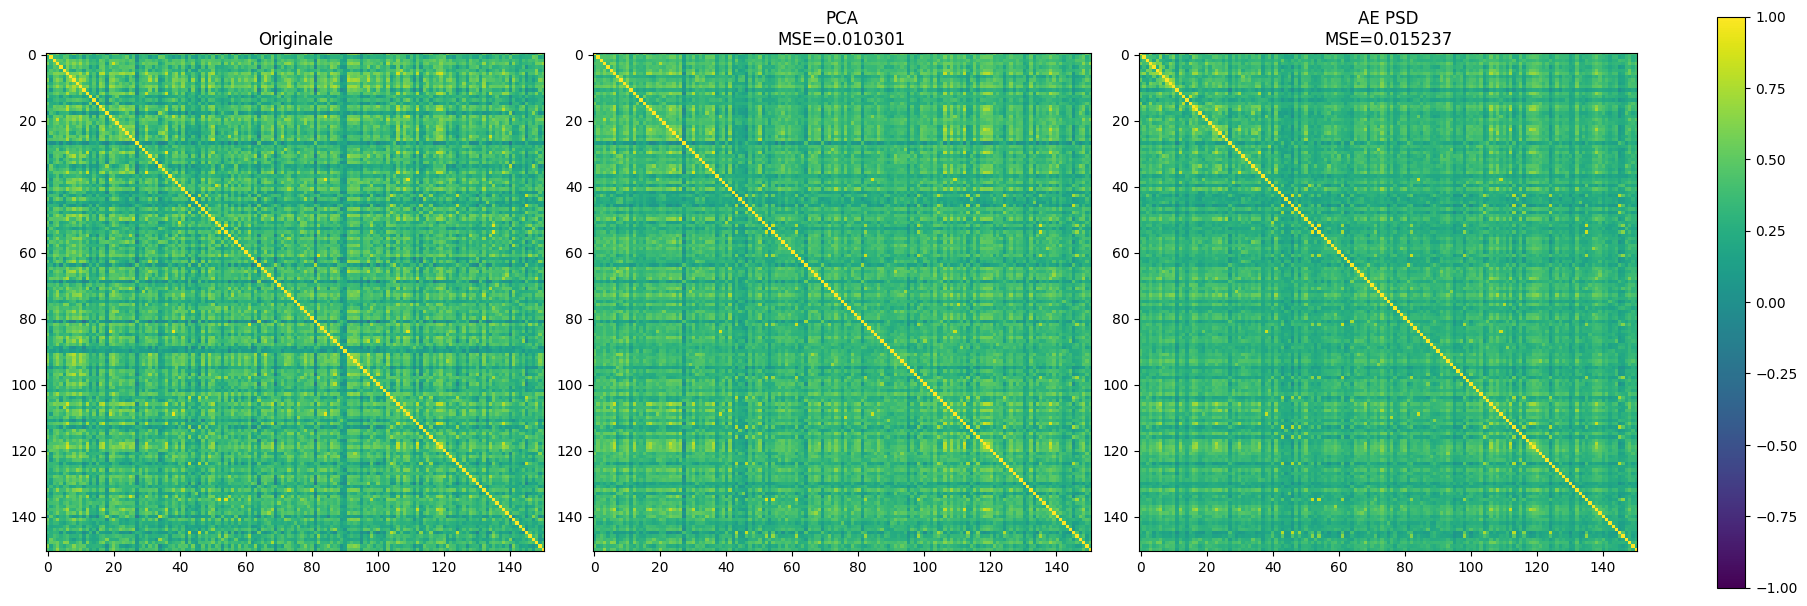

In [103]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(18,6),
    constrained_layout=True
)

# Originale
im = axes[0].imshow(
    C_true,
    vmin=-1,
    vmax=1
)

axes[0].set_title("Originale")

# PCA
axes[1].imshow(
    C_pca,
    vmin=-1,
    vmax=1
)

axes[1].set_title(
    f"PCA\nMSE={mse_pca:.6f}"
)

# AE
axes[2].imshow(
    C_ae,
    vmin=-1,
    vmax=1
)

axes[2].set_title(
    f"AE PSD\nMSE={mse_ae:.6f}"
)

fig.colorbar(im, ax=axes)

plt.show()

In [104]:
# 
# confrontare gli spettri.

eig_true = np.sort(
    np.linalg.eigvalsh(C_true)
)[::-1]

eig_pca = np.sort(
    np.linalg.eigvalsh(C_pca)
)[::-1]

eig_ae = np.sort(
    np.linalg.eigvalsh(C_ae)
)[::-1]

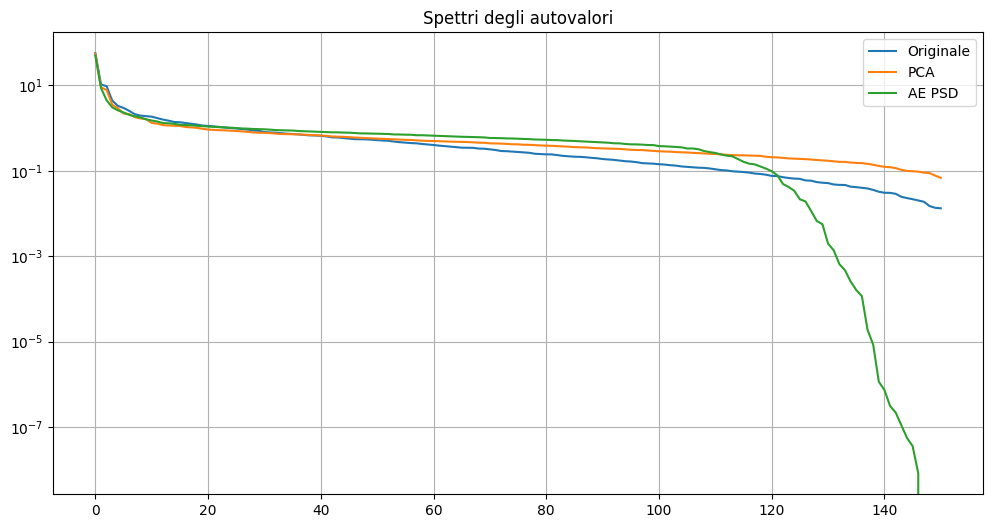

In [105]:
plt.figure(figsize=(12,6))

plt.plot(eig_true, label="Originale")

plt.plot(eig_pca, label="PCA")

plt.plot(eig_ae, label="AE PSD")

plt.yscale("log")

plt.grid(True)

plt.legend()

plt.title("Spettri degli autovalori")

plt.show()

In [106]:
# 
# controllare PSD.

print("Min eigenvalue originale:",
      eig_true.min())

print("Min eigenvalue PCA:",
      eig_pca.min())

print("Min eigenvalue AE:",
      eig_ae.min())

Min eigenvalue originale: 0.01317609108959115
Min eigenvalue PCA: 0.0682758891522248
Min eigenvalue AE: -1.1999285e-07


In [107]:
# 
# vedere come evolve l'errore nel tempo.

pca_errors = []

ae_errors = []

for i in range(len(X_test)):

    C_true = upper_vec_to_corr_matrix(
        X_test[i],
        N
    )

    C_pca = upper_vec_to_corr_matrix(
        X_test_rec_pca[i],
        N
    )

    C_ae = C_test_ae[i]

    pca_errors.append(
        np.mean((C_true - C_pca)**2)
    )

    ae_errors.append(
        np.mean((C_true - C_ae)**2)
    )

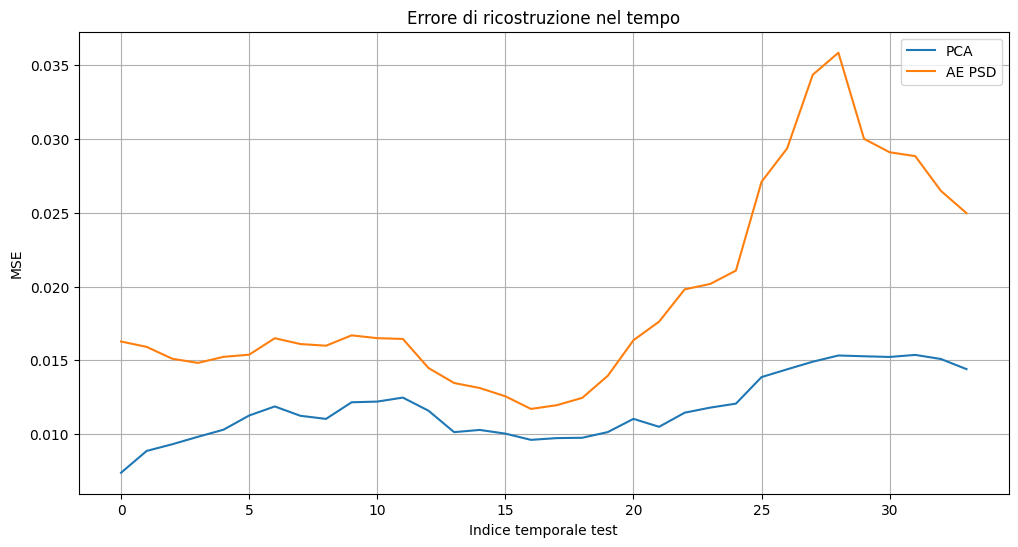

In [108]:
plt.figure(figsize=(12,6))

plt.plot(
    pca_errors,
    label="PCA"
)

plt.plot(
    ae_errors,
    label="AE PSD"
)

plt.legend()

plt.grid(True)

plt.title("Errore di ricostruzione nel tempo")

plt.xlabel("Indice temporale test")

plt.ylabel("MSE")

plt.show()